# Laboratorio: diferencias finitas para EDPs — guía del docente

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jfbonder/imc/blob/main/notebooks/docente/lab-EDP-numerico.ipynb)

> Versión con las soluciones completas. La versión para estudiantes, con esqueletos en lugar de las soluciones, es `notebooks/lab-EDP-numerico.ipynb`.

Este laboratorio es del mismo tipo que el de EDOs: las notas (Capítulos 18–20) resuelven la difusión, Laplace/Poisson y las ondas con series de Fourier y fórmulas exactas, pero **no dicen qué hacer cuando no hay fórmula**. En cuanto el dominio, el dato o los coeficientes se complican, lo que se hace en la práctica es *discretizar*. Los métodos de **diferencias finitas** no están en las notas: el texto de este notebook es la única presentación que van a tener, así que léanlo con cuidado y no solo las consignas.

**Qué vamos a hacer.** *Parte A (espacio, Tareas 1–5):* construir matrices de diferenciación a partir del desarrollo de Taylor, medir órdenes de convergencia, resolver Poisson en 1D con condiciones de Dirichlet y de Neumann, y estudiar una ecuación con capa límite donde el esquema "obvio" falla. *Parte B (tiempo, Tareas 6–10):* el esquema explícito para el calor (y por qué explota si $r>1/2$), el implícito, y el esquema centrado (*leapfrog*) para ondas con la condición CFL.

**Herramientas disponibles.** `imc.numerico` trae implementaciones de referencia: `matriz_laplaciano_1d`, `calor_explicito`, `calor_implicito`, `ondas_leapfrog` (1D) y `laplaciano_2d`, `poisson_cinco_puntos` (2D). Las usamos para *verificar* lo que ustedes escriban, no en lugar de escribirlo. Los notebooks 09 (calor) y 11 (ondas) del texto las usan como cajas negras; acá abrimos la caja.

**Cómo se evalúa.** Lo que se evalúa es la **interpretación escrita** del final, no el código. Cada tarea dice qué se espera y trae una celda de verificación que avisa si van bien. Tiempo estimado: dos sesiones de laboratorio (Parte A y Parte B) o una muy larga.

In [1]:
# Configuración (funciona en Colab y en una copia local del repositorio)
try:
    import imc
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/jfbonder/imc.git"], check=True)
    import imc

import numpy as np
import matplotlib.pyplot as plt
from imc import estilo, datos
from imc.estilo import COLORES
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.linalg import solve_banded
from imc import numerico
from imc.estilo import CICLO
import time, math
estilo.activar()

# Parte A. Discretización en el espacio

## 1. De Taylor a las matrices de diferenciación

**Grilla.** En $[a,b]$ tomamos $N$ subintervalos, $h = (b-a)/N$ y los nodos $x_j = a + jh$, $j = 0,\dots,N$. Una función $u$ se representa por el vector $U_j \approx u(x_j)$. Aproximar una derivada es dar una combinación lineal de valores nodales que se le parezca.

**Taylor.** Si $u$ es suave,
$$u(x\pm h) = u(x) \pm h\,u'(x) + \tfrac{h^2}{2}u''(x) \pm \tfrac{h^3}{6}u'''(x) + \tfrac{h^4}{24}u^{(4)}(x)\pm\cdots$$
De ahí salen los tres esquemas del enunciado:

* *forward:* $\dfrac{u(x+h)-u(x)}{h} = u'(x) + \tfrac h2 u''(x) + O(h^2)$;
* *backward:* $\dfrac{u(x)-u(x-h)}{h} = u'(x) - \tfrac h2 u''(x) + O(h^2)$;
* *centrada:* $\dfrac{u(x+h)-u(x-h)}{2h} = u'(x) + \tfrac{h^2}{6}u'''(x) + O(h^4)$ (los términos pares se cancelan).

La diferencia entre el esquema y la derivada exacta es el **error de truncamiento**. Si es $O(h^p)$ se dice que el esquema es **consistente de orden $p$**. Forward y backward son de orden 1, la centrada de orden 2. Para la segunda derivada, $\frac{u(x+h)-2u(x)+u(x-h)}{h^2} = u'' + \frac{h^2}{12}u^{(4)} + \cdots$ es de orden 2.

**Esquemas generales.** Un esquema para $u^{(d)}(x)$ con esténcil $\{o_0,\dots,o_{n-1}\}$ (enteros distintos, los nodos son $x+o_kh$) es $\sum_k w_k\,u(x+o_kh) \approx h^d u^{(d)}(x)$. Por Taylor, $\sum_k w_k u(x+o_kh) = \sum_m \frac{h^m}{m!}\bigl(\sum_k w_k o_k^m\bigr)u^{(m)}(x)$, así que los pesos tienen que cumplir
$$\sum_k w_k\,\frac{o_k^m}{m!} = \delta_{m,d},\qquad m = 0,\dots,n-1,$$
un sistema lineal $Vw = e_d$ con $V_{mk} = o_k^m/m!$ (matriz de Vandermonde, invertible porque los $o_k$ son distintos). Con $n$ nodos se logra orden al menos $n-d$, y uno más si el esquema es simétrico y $n-d$ es impar. Es exactamente lo mismo que interpolar $u$ con el polinomio de grado $n-1$ que pasa por los $n$ nodos y derivarlo (el ejercicio de interpolación y fórmulas de orden superior en "Ejercicios de laboratorio" de la Parte III, Sección 21.2): los pesos son los de $p'(x)$. Ejemplo: con $\{-1,0,1\}$ y $d=2$ el sistema da $w = (1,-2,1)$.

**Matrices de diferenciación.** Aplicar un esquema en todos los nodos es multiplicar por una matriz: $U'\approx DU$.

* *Grilla con extremos (no periódica).* El esquema forward necesita $x_{j+1}$, así que sólo se aplica en $j=0,\dots,N-1$; el backward en $j=1,\dots,N$; el centrado en $j=1,\dots,N-1$; uno de cinco puntos en $j=2,\dots,N-2$. Es el "subconjunto adecuado de los nodos" del enunciado: $D$ es rectangular, $(\#\text{filas})\times(N+1)$, y hay que devolver también qué nodos corresponden a cada fila.
* *Periódica* ($u(a)=u(b)$, o sea $x_N\equiv x_0$). Hay $N$ incógnitas $U_0,\dots,U_{N-1}$ y los índices se toman módulo $N$: $D$ es cuadrada y **circulante**, y se puede aplicar en todos los nodos.

En ambos casos las filas suman cero (una constante tiene derivada cero) y cada fila tiene sólo 2–5 elementos no nulos: son matrices **ralas**. Acá $N\le 256$ y usamos matrices densas; en la Tarea 3 vamos a ver por qué en problemas grandes eso deja de ser razonable.

**Para pensar (no hay celda).** (i) Con Taylor, comprobá que el error del esquema de cinco puntos $\{-2,-1,0,1,2\}$ es $\frac{h^4}{30}u^{(5)}(x)+\cdots$. (ii) ¿Por qué las fórmulas centradas ganan un orden "gratis" y las laterales no? (iii) Ese ejercicio pide interpolar en $x-2h,x-h,x$ y derivar: mostrá que da $\frac{3u(x)-4u(x-h)+u(x-2h)}{2h}$ y verificá que coincide con lo que da el sistema de Vandermonde.

### Tarea 1: Pesos de Taylor y matrices de diferenciación

Escribí:

* `pesos_taylor(offsets, d=1)`: resuelve el sistema $Vw=e_d$ y devuelve los pesos $w_k$ (para $h=1$).
* `matriz_dif(offsets, pesos, N, h, periodica=False, d=1)`: devuelve `(D, idx)`, donde `D` es la matriz de diferenciación (con el factor $1/h^d$ incluido) y `idx` los índices de los nodos en los que el esquema está definido. En el caso no periódico `D` tiene forma `(len(idx), N+1)`; en el periódico `(N, N)` con `idx = arange(N)`.
* `dif_forward`, `dif_backward`, `dif_centrada` (llaman a `matriz_dif` con el esténcil correspondiente).

Después obtené con `pesos_taylor` los pesos de los dos esquemas del ejercicio de interpolación (Sección 21.2): backward de orden 2 con $\{-2,-1,0\}$ y centrado de orden 4 con $\{-2,-1,0,1,2\}$, y escribilos en un comentario.

**Qué se espera.** Que la celda de verificación no proteste. Chequeá a mano que $\{-2,-1,0\}$ da $\frac12(1,-4,3)$ y que el de cinco puntos da $\frac1{12}(1,-8,0,8,-1)$. Errores típicos: olvidarse de dividir por $h^d$, indexar mal el caso periódico (`(j+o) % N`) y aplicar la matriz periódica a $N+1$ valores (el último nodo es el primero repetido).

In [2]:
def pesos_taylor(offsets, d=1):
    """Pesos w_k con sum_k w_k u(x + o_k h) ~ h^d u^(d)(x) (para h = 1)."""
    o = np.asarray(offsets, dtype=float)
    n = len(o)
    V = np.array([o ** m / math.factorial(m) for m in range(n)])
    b = np.zeros(n); b[d] = 1.0
    return np.linalg.solve(V, b)

def matriz_dif(offsets, pesos, N, h, periodica=False, d=1):
    """Matriz de diferenciación del esténcil (offsets, pesos) en x_j = a + j h, j = 0..N.
    Devuelve (D, idx). Periódica: D es (N, N), idx = arange(N). No periódica: D es (len(idx), N+1)."""
    offsets = list(offsets)
    if periodica:
        idx = np.arange(N)
        D = np.zeros((N, N))
        for j in idx:
            for o, w in zip(offsets, pesos):
                D[j, (j + o) % N] += w
    else:
        idx = np.arange(max(0, -min(offsets)), N - max(0, max(offsets)) + 1)
        D = np.zeros((len(idx), N + 1))
        for i, j in enumerate(idx):
            for o, w in zip(offsets, pesos):
                D[i, j + o] += w
    return D / h ** d, idx

def dif_forward(N, h, periodica=False):
    return matriz_dif([0, 1], pesos_taylor([0, 1]), N, h, periodica)

def dif_backward(N, h, periodica=False):
    return matriz_dif([-1, 0], pesos_taylor([-1, 0]), N, h, periodica)

def dif_centrada(N, h, periodica=False):
    return matriz_dif([-1, 0, 1], pesos_taylor([-1, 0, 1]), N, h, periodica)

print("backward 2:  ", pesos_taylor([-2, -1, 0]) * 2, "/ (2h)")
print("centrada 4:  ", pesos_taylor([-2, -1, 0, 1, 2]) * 12, "/ (12h)")
print("segunda derivada centrada:", pesos_taylor([-1, 0, 1], d=2))

backward 2:   [ 1. -4.  3.] / (2h)
centrada 4:   [ 1.00000000e+00 -8.00000000e+00  1.33226763e-15  8.00000000e+00
 -1.00000000e+00] / (12h)
segunda derivada centrada: [ 1. -2.  1.]


In [3]:
# Verificación
assert np.allclose(pesos_taylor([0, 1]), [-1, 1]) and np.allclose(pesos_taylor([-1, 0, 1]), [-0.5, 0, 0.5])
assert np.allclose(pesos_taylor([-1, 0, 1], d=2), [1, -2, 1])
assert np.allclose(pesos_taylor([-2, -1, 0]), [0.5, -2, 1.5])
assert np.allclose(pesos_taylor([-2, -1, 0, 1, 2]), np.array([1, -8, 0, 8, -1]) / 12)
N, h = 16, 1 / 16
x = np.arange(N + 1) * h
for offs in ([0, 1], [-1, 0], [-1, 0, 1], [-2, -1, 0], [-2, -1, 0, 1, 2]):
    w = pesos_taylor(offs)
    D, idx = matriz_dif(offs, w, N, h)
    deg = len(offs) - 1                                  # el esquema es exacto para polinomios de grado <= n-1
    assert np.allclose(D @ x ** deg, deg * x[idx] ** (deg - 1)), f"no es exacto para grado {deg}: {offs}"
    Dp, idxp = matriz_dif(offs, w, N, h, periodica=True)
    assert Dp.shape == (N, N) and np.allclose(Dp.sum(axis=1), 0)
assert list(dif_forward(N, h)[1]) == list(range(N)) and list(dif_backward(N, h)[1]) == list(range(1, N + 1))
assert list(dif_centrada(N, h)[1]) == list(range(1, N))
Dc, _ = dif_centrada(N, h, periodica=True)
err = np.abs(Dc @ np.sin(2 * np.pi * x[:N]) - 2 * np.pi * np.cos(2 * np.pi * x[:N])).max()
print(f"centrada periódica sobre sin(2 pi x): error {err:.3f} (h = 1/16)")
print("matrices de diferenciación: OK")

centrada periódica sobre sin(2 pi x): error 0.160 (h = 1/16)
matrices de diferenciación: OK


## 2. Medir el orden de convergencia (y qué rompe la periodicidad)

Si el error de un esquema es $e(h)\approx Ch^p$, entonces $\log e = \log C + p\log h$: en un gráfico log-log del error contra $h$ los puntos caen sobre una recta de pendiente $p$. Como norma del error usamos la del máximo, $\|e\|_\infty=\max_j|e_j|$ (en los nodos donde el esquema está definido). Se usa $h_i = 2^{-i}$, $i=3,\dots,8$, así que cada punto tiene la mitad de $h$ que el anterior: si el orden es $p$, el cociente de errores consecutivos tiende a $2^p$ (2, 4, 16 para $p=1,2,4$).

Dos advertencias prácticas. (1) La estimación vale para $h$ chico: los primeros puntos pueden apartarse de la recta, así que conviene ajustar sólo con los últimos tres o cuatro (`ultimos=3`). (2) Para $p$ alto el error llega rápido al piso del redondeo ($\sim 10^{-16}/h$) y la curva se aplana; con $h\ge 2^{-8}$ y $p\le 4$ no es problema.

**Las dos funciones de prueba.** $u(x)=\log(x+1)-\log(2)\,x$ y $v(x)=e^{\cos 2\pi x}$ en $[0,1]$. Las dos toman el mismo valor en los extremos ($u(0)=u(1)=0$, $v(0)=v(1)=e$), o sea que las dos son continuas como funciones periódicas. La diferencia es más fina: $v$ es *suave* como función periódica ($v'(0)=v'(1)$, y lo mismo para todas las derivadas), mientras que $u'(0)=1-\log 2\approx0.307$ y $u'(1)=\tfrac12-\log2\approx-0.193$ **no coinciden**: la extensión periódica de $u$ tiene una *punta* en los extremos.

**Predecí antes de correr.** Un esquema periódico, en el nodo $x_0$, usa valores "de más allá" de $x_N$ como si fueran los de la izquierda de $x_0$. ¿Qué nodos usa cada esquema (forward, backward, centrado, los de orden 2 y 4) en $x_0$ y en $x_{N-1}$? ¿Cuáles de ellos se ven afectados por la punta? Anotá tu predicción, que después se contrasta con la tabla.

In [4]:
def orden_empirico(hs, errores, ultimos=None):
    """Pendiente de log(errores) contra log(hs) (ajuste por mínimos cuadrados), opcionalmente con los últimos puntos."""
    hs, errores = np.asarray(hs), np.asarray(errores)
    if ultimos:
        hs, errores = hs[-ultimos:], errores[-ultimos:]
    return np.polyfit(np.log(hs), np.log(errores), 1)[0]

### Tarea 2: Orden de los esquemas de diferenciación; periódicas contra no periódicas

Con `matriz_dif` y `pesos_taylor` de la Tarea 1, evaluá los cinco esquemas (forward, backward, centrada, backward de orden 2, centrada de orden 4) sobre $u$ y $v$, en versión no periódica y periódica, con $N=2^i$, $i=3,\dots,8$. Escribí `error_dif(f, df, offsets, periodica)`, que devuelve el array de errores $\|Df-f'\|_\infty$ (en los nodos de `idx`). Cuidado: en el caso periódico se aplica a `f(x[:N])`.

Después: (1) una figura de $2\times2$ paneles log-log (filas $u$, $v$; columnas no periódica, periódica) con una curva por esquema y el orden estimado en la leyenda; (2) una tabla con los órdenes; (3) para $u$ con esquemas periódicos, una figura del error $|Du-u'|$ en función de $x$ (escala semilogarítmica, $N=64$): *dónde* está el error.

**Qué se espera.** Para $v$ (ambas versiones) los órdenes 1, 1, 2, 2, 4. Para $u$ no periódica, lo mismo. Para $u$ periódica, casi todo se rompe: el error deja de bajar (orden 0). Pero **no todo**: mirá bien la fila de forward y comparala con tu predicción. Explicá en una línea por qué.

             | u no p | u per  | v no p | v per 
     forward |     0.99 |     0.99 |     1.00 |     1.00
    backward |     0.99 |    -0.00 |     1.00 |     1.00
    centrada |     1.97 |     0.01 |     2.00 |     2.00
  backward 2 |     1.97 |     0.00 |     2.00 |     2.00
  centrada 4 |     3.92 |     0.00 |     3.99 |     3.99


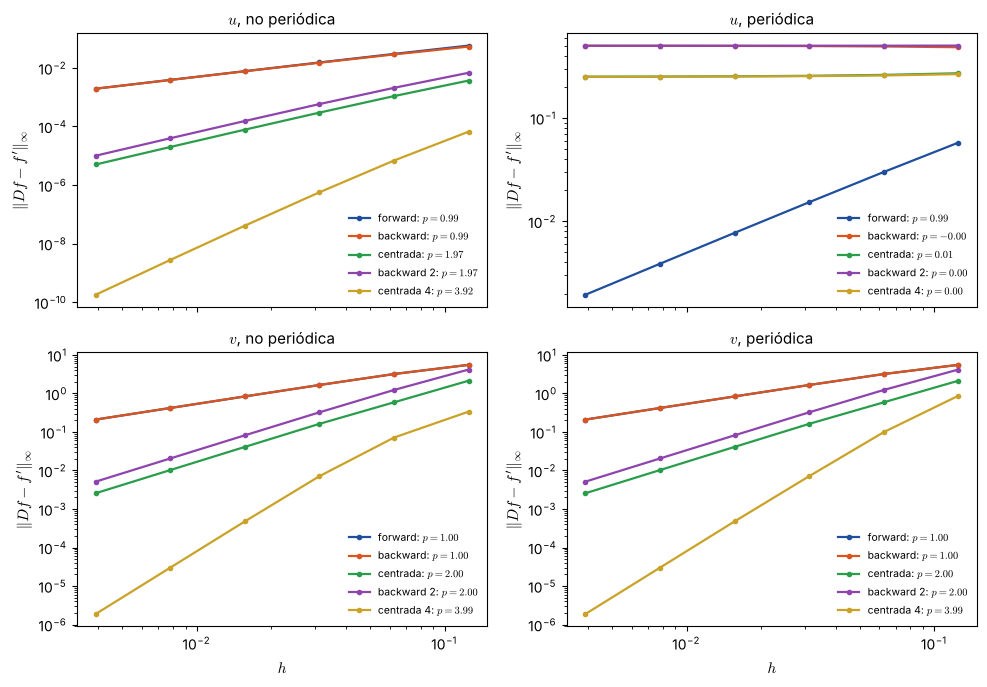

In [5]:
u  = lambda x: np.log(x + 1) - np.log(2) * x
du = lambda x: 1 / (x + 1) - np.log(2)
v  = lambda x: np.exp(np.cos(2 * np.pi * x))
dv = lambda x: -2 * np.pi * np.sin(2 * np.pi * x) * v(x)
esquemas = {"forward": [0, 1], "backward": [-1, 0], "centrada": [-1, 0, 1],
            "backward 2": [-2, -1, 0], "centrada 4": [-2, -1, 0, 1, 2]}
Ns = 2 ** np.arange(3, 9); hs = 1 / Ns

def error_dif(f, df, offsets, periodica, N_lista=None):
    """Errores max|D f - f'| en los nodos de idx, para cada N en Ns (h = 1/N, intervalo [0,1])."""
    errs = []
    for N in (Ns if N_lista is None else N_lista):
        h = 1 / N; x = np.arange(N + 1) * h
        D, idx = matriz_dif(offsets, pesos_taylor(offsets), N, h, periodica)
        fx = f(x[:N]) if periodica else f(x)
        errs.append(np.abs(D @ fx - df(x[idx])).max())
    return np.array(errs)

err = {(nf, per, ne): error_dif(f, df, offs, per)
       for nf, (f, df) in {"u": (u, du), "v": (v, dv)}.items()
       for per in (False, True) for ne, offs in esquemas.items()}

fig, axs = plt.subplots(2, 2, figsize=(10, 7), sharex=True)
for i, nf in enumerate(["u", "v"]):
    for j, per in enumerate([False, True]):
        ax = axs[i, j]
        for c, ne in zip(CICLO, esquemas):
            e = err[(nf, per, ne)]
            ax.loglog(hs, e, "o-", ms=3, color=c, label=f"{ne}: $p={orden_empirico(hs, e, 3):.2f}$")
        ax.set_title(f"${nf}$, " + ("periódica" if per else "no periódica"))
        ax.legend(fontsize=7.5, loc="lower right"); ax.set_ylabel(r"$\|Df-f'\|_\infty$")
for ax in axs[1]:
    ax.set_xlabel("$h$")
fig.tight_layout()

print(f"{'':>12s} | " + " | ".join(f"{nf} {'per ' if per else 'no p'}" for nf in 'uv' for per in (False, True)))
for ne in esquemas:
    print(f"{ne:>12s} | " + " | ".join(f"{orden_empirico(hs, err[(nf, per, ne)], 3):8.2f}" for nf in 'uv' for per in (False, True)))

In [6]:
# Verificación
p = lambda nf, per, ne: orden_empirico(hs, err[(nf, per, ne)], ultimos=3)
assert 0.8 < p("v", False, "forward") < 1.2 and 0.8 < p("v", True, "backward") < 1.2, "forward/backward: orden 1"
assert 1.8 < p("v", True, "centrada") < 2.2 and 1.8 < p("v", False, "backward 2") < 2.2, "centrada y backward 2: orden 2"
assert 3.6 < p("v", True, "centrada 4") < 4.4, "centrada 4: orden 4"
assert 1.8 < p("u", False, "centrada") < 2.2, "u no periódica: el orden se mantiene"
assert err[("u", True, "centrada")][-1] > 0.1, "u periódica con centrada: el error no debería bajar de 0.1"
print("órdenes: OK")

órdenes: OK


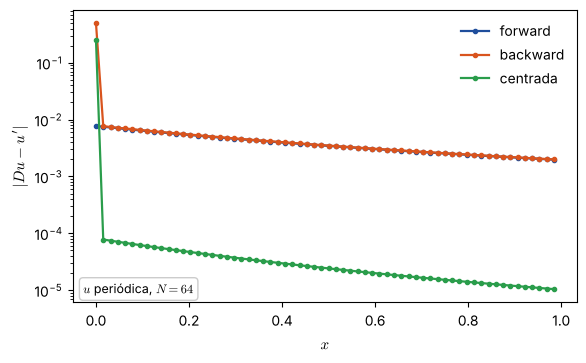

In [7]:
# Figura 3: dónde está el error de u con esquemas periódicos (N = 64)
N = 64; h = 1 / N; x = np.arange(N + 1) * h
fig, ax = plt.subplots(figsize=(6.5, 3.8))
for c, ne in zip(CICLO, ["forward", "backward", "centrada"]):
    D, idx = matriz_dif(esquemas[ne], pesos_taylor(esquemas[ne]), N, h, periodica=True)
    ax.semilogy(x[idx], np.abs(D @ u(x[:N]) - du(x[idx])) + 1e-17, "o-", ms=3, color=c, label=ne)
ax.set_xlabel("$x$"); ax.set_ylabel(r"$|Du-u'|$"); ax.legend()
estilo.parametros(ax, r"$u$ periódica, $N=64$", loc="lower left")

**Para el docente.** Lo que suele pasar: (i) los estudiantes esperan que *todo* falle con $u$ periódica y se sorprenden con forward. La razón: $u(0)=u(1)$, y forward en el último nodo usa $x_{N}\equiv x_0$, cuyo valor coincide con el de $x_N$, el nodo verdadero; forward nunca mira "del otro lado" con un valor equivocado. Backward en $x_0$ usa $u(1-h)$ en lugar de $u(-h)$: el cociente da $\approx u'(1^-)$, y el error es $u'(0)-u'(1)=1/2$. Centrada en $x_0$ da el promedio de $u'(0)$ y $u'(1)$: error $1/4$ (medido: $0.4995$ y $0.2507$). (ii) Las curvas de orden 4 y orden 2 de $v$ tienen las pendientes esperadas; las de $u$ periódica son horizontales. Tiempo: 25 minutos.

## 3. Poisson en 1D con condiciones de Dirichlet: un sistema lineal, y su costo

Queremos resolver $u''(x)=f(x)$ en $(0,1)$ con $u(0)=\alpha$, $u(1)=\beta$. Tomamos $h=1/(m+1)$, los nodos $x_j=jh$, $j=0,\dots,m+1$, e incógnitas $U_1,\dots,U_m$ (los extremos son datos: $U_0=\alpha$, $U_{m+1}=\beta$). En cada nodo interior imponemos el esquema centrado de la segunda derivada:
$$\frac{U_{j-1}-2U_j+U_{j+1}}{h^2}=f(x_j),\qquad j=1,\dots,m.$$
Los datos de borde pasan al lado derecho: en $j=1$ aparece $U_0=\alpha$ y en $j=m$ aparece $U_{m+1}=\beta$. Queda un sistema $AU=b$ con
$$A=\frac1{h^2}\begin{pmatrix}-2&1&&\\1&-2&1&\\&\ddots&\ddots&\ddots\\&&1&-2\end{pmatrix},\qquad b_j=f(x_j)\ \ (j\ne 1,m),\quad b_1=f(x_1)-\frac{\alpha}{h^2},\quad b_m=f(x_m)-\frac{\beta}{h^2}.$$
`numerico.matriz_laplaciano_1d(m, h)` construye $A$: la usamos para verificar.

**Orden.** El error de truncamiento es $\frac{h^2}{12}u^{(4)}$. Para pasar de eso al error global $e=U-u|_{\text{nodos}}$ hace falta además que $A$ sea *estable*: $Ae=\tau$ (el truncamiento), o sea $e=A^{-1}\tau$, y $\|A^{-1}\|_\infty\le\frac18$ para todo $h$ (la solución de $u''=1$, $u(0)=u(1)=0$ es $\frac{x^2-x}2$, cuyo máximo es $\frac18$). Entonces $\|e\|_\infty\le\frac{1}{8}\|\tau\|_\infty=O(h^2)$: **consistencia + estabilidad ⇒ convergencia**. Esa misma estructura de argumento vuelve en la Parte B con otra hipótesis de estabilidad.

**Costo.** Resolver un sistema denso $m\times m$ por eliminación gaussiana cuesta $O(m^3)$ operaciones y $O(m^2)$ memoria. Pero $A$ es **tridiagonal**: sólo tiene $3m$ elementos no nulos y se resuelve en $O(m)$. `np.diag` arma la matriz densa (con los $m^2-3m$ ceros incluidos). `scipy.sparse.spdiags` (o `sp.diags`) guarda sólo las diagonales, y `spla.spsolve` usa una factorización rala. Un tercer camino, específico para matrices en banda, es `scipy.linalg.solve_banded`: recibe las tres diagonales en un array de $3\times m$ (`ab[0,1:]` = superdiagonal, `ab[1]` = diagonal, `ab[2,:-1]` = subdiagonal) y es el que vamos a usar en la Parte B.

**Cómo medir tiempos.** Con `time.time()` antes y después. Medí armado + resolución (es lo que le importa al usuario) y quedate con el mínimo de tres repeticiones para reducir el ruido. Para el denso limitá $m\le 2^{11}$ (la matriz de $2^{12}$ ya ocupa 128 MB).

### Tarea 3: Poisson con np.diag y con scipy.sparse; tiempos

Con $u(x)=e^x+\sin 3\pi x$ (entonces $f=u''=e^x-9\pi^2\sin 3\pi x$, $\alpha=u(0)$, $\beta=u(1)$) escribí tres funciones `poisson_dense`, `poisson_sparse` y `poisson_banded`, que devuelven `(x, U)` en los $m$ nodos interiores:

* (a) armando $A$ con `np.diag` y resolviendo con `np.linalg.solve`;
* (b) armando $A$ con `scipy.sparse.spdiags` y resolviendo con `spla.spsolve` (necesita formato CSC o CSR);
* (c) armando las diagonales para `solve_banded`.

Con $m=2^k-1$ (o sea $h=2^{-k}$): (1) verificá que las tres dan la misma solución y estimá el orden del error $\|U-u\|_\infty$; (2) medí el tiempo de cada una en función de $h$ ($k=4,\dots,11$ para el denso; hasta $k=17$ para las otras dos) y graficá tiempo contra $m$ en escala log-log.

**Qué se espera.** Orden 2 en el error. En el gráfico de tiempos, el denso con pendiente entre 2 y 3 (el armado $O(m^2)$ y el paralelismo de BLAS suavizan el $m^3$ teórico; medido: $\approx2.2$) y las ralas con pendiente cercana a 1, con `solve_banded` un poco por debajo de `spsolve` (menos sobrecarga). Anotá el tiempo del denso con $m=2047$ y el de `solve_banded` con $m$ cien mil: ¿cuántas veces más rápido es este último, teniendo *cincuenta* veces más incógnitas?

orden empírico del error: 2.002


pendiente del tiempo (denso, últimos 4): 0.27; spsolve: 1.54; banded: 1.24
denso m=2047: 0.883 s;  banded m=131071: 0.0135 s


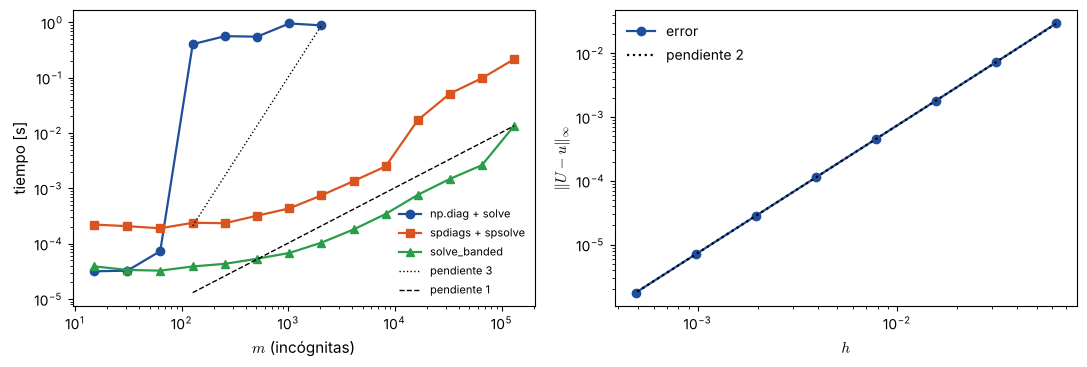

In [8]:
uex = lambda x: np.exp(x) + np.sin(3 * np.pi * x)
f   = lambda x: np.exp(x) - 9 * np.pi ** 2 * np.sin(3 * np.pi * x)
alpha, beta = uex(0.0), uex(1.0)

def _rhs(f, alpha, beta, m):
    h = 1 / (m + 1); x = h * np.arange(1, m + 1)
    b = f(x).copy(); b[0] -= alpha / h ** 2; b[-1] -= beta / h ** 2
    return h, x, b

def poisson_dense(f, alpha, beta, m):
    """u'' = f, u(0) = alpha, u(1) = beta, con np.diag. Devuelve (x, U) en los m nodos interiores."""
    h, x, b = _rhs(f, alpha, beta, m)
    A = (np.diag(-2 * np.ones(m)) + np.diag(np.ones(m - 1), 1) + np.diag(np.ones(m - 1), -1)) / h ** 2
    return x, np.linalg.solve(A, b)

def poisson_sparse(f, alpha, beta, m):
    """Ídem con scipy.sparse.spdiags y spsolve."""
    h, x, b = _rhs(f, alpha, beta, m)
    e = np.ones(m)
    A = sp.spdiags([e, -2 * e, e], [-1, 0, 1], m, m, format="csc") / h ** 2
    return x, spla.spsolve(A, b)

def poisson_banded(f, alpha, beta, m):
    """Ídem con scipy.linalg.solve_banded."""
    h, x, b = _rhs(f, alpha, beta, m)
    ab = np.zeros((3, m)); ab[0, 1:] = 1; ab[1] = -2; ab[2, :-1] = 1
    return x, solve_banded((1, 1), ab / h ** 2, b)

def tiempo(fun, m, rep=3):
    """Mínimo de rep mediciones del tiempo de fun(f, alpha, beta, m)."""
    ts = []
    for _ in range(rep):
        t0 = time.time(); fun(f, alpha, beta, m); ts.append(time.time() - t0)
    return min(ts)

ks = np.arange(4, 12)
hs_p = 2.0 ** -ks
err_p = [np.abs(poisson_banded(f, alpha, beta, 2 ** k - 1)[1] - uex(poisson_banded(f, alpha, beta, 2 ** k - 1)[0])).max() for k in ks]
print("orden empírico del error:", round(orden_empirico(hs_p, err_p), 3))

ks_r = np.arange(4, 18)
t_dense = [tiempo(poisson_dense, 2 ** k - 1) for k in ks]
t_sp = [tiempo(poisson_sparse, 2 ** k - 1) for k in ks_r]
t_bd = [tiempo(poisson_banded, 2 ** k - 1) for k in ks_r]
ms, ms_r = 2.0 ** ks - 1, 2.0 ** ks_r - 1
print(f"pendiente del tiempo (denso, últimos 4): {np.polyfit(np.log(ms[-4:]), np.log(t_dense[-4:]), 1)[0]:.2f}; "
      f"spsolve: {np.polyfit(np.log(ms_r[-5:]), np.log(t_sp[-5:]), 1)[0]:.2f}; banded: {np.polyfit(np.log(ms_r[-5:]), np.log(t_bd[-5:]), 1)[0]:.2f}")
print(f"denso m=2047: {t_dense[-1]:.3f} s;  banded m={2**17-1}: {t_bd[-1]:.4f} s")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))
ax1.loglog(ms, t_dense, "o-", label="np.diag + solve")
ax1.loglog(ms_r, t_sp, "s-", label="spdiags + spsolve")
ax1.loglog(ms_r, t_bd, "^-", label="solve_banded")
ax1.loglog(ms[3:], t_dense[-1] * (ms[3:] / ms[-1]) ** 3, "k:", lw=1, label="pendiente 3")
ax1.loglog(ms_r[3:], t_bd[-1] * (ms_r[3:] / ms_r[-1]), "k--", lw=1, label="pendiente 1")
ax1.set_xlabel("$m$ (incógnitas)"); ax1.set_ylabel("tiempo [s]"); ax1.legend(fontsize=8)
ax2.loglog(hs_p, err_p, "o-", label="error")
ax2.loglog(hs_p, err_p[-1] * (hs_p / hs_p[-1]) ** 2, "k:", label="pendiente 2")
ax2.set_xlabel("$h$"); ax2.set_ylabel(r"$\|U-u\|_\infty$"); ax2.legend()
fig.tight_layout()

In [9]:
# Verificación: las tres coinciden entre sí y con la referencia de imc.numerico
m = 100; h = 1 / (m + 1)
x, U1 = poisson_dense(f, alpha, beta, m)
U2 = poisson_sparse(f, alpha, beta, m)[1]; U3 = poisson_banded(f, alpha, beta, m)[1]
b = f(x).copy(); b[0] -= alpha / h ** 2; b[-1] -= beta / h ** 2
Uref = np.linalg.solve(numerico.matriz_laplaciano_1d(m, h), b)
assert np.allclose(U1, Uref) and np.allclose(U2, Uref) and np.allclose(U3, Uref), "no coincide con la referencia"
e1, e2 = [np.abs(poisson_banded(f, alpha, beta, 2 ** k - 1)[1] - uex(poisson_banded(f, alpha, beta, 2 ** k - 1)[0])).max() for k in (6, 7)]
assert 3.5 < e1 / e2 < 4.5, "al duplicar la cantidad de nodos el error debería dividirse por ~4"
print("Poisson Dirichlet: OK   (||A^-1||_inf =", round(np.abs(np.linalg.inv(numerico.matriz_laplaciano_1d(m, h))).sum(axis=1).max(), 4), ")")

Poisson Dirichlet: OK   (||A^-1||_inf = 0.125 )


**Una mirada al 2D (ya resuelto con `imc.numerico`).** Con el esquema de cinco puntos en el cuadrado, con $n\times n$ nodos hay $\sim n^2$ incógnitas y la matriz es rala con 5 elementos por fila (`numerico.laplaciano_2d`, armada con productos de Kronecker de la 1D). Para $n=320$ son 100 mil incógnitas: una matriz densa ocuparía 80 GB, y la rala se resuelve en menos de un segundo. Es *el* motivo por el que se usan matrices ralas.

In [10]:
# -Δu = 2π² sin(πx) sin(πy) en [0,1]², u = 0 en el borde: solución exacta sin(πx) sin(πy)
for n in [20, 40, 80, 160, 320]:
    xx = np.linspace(0, 1, n + 1); X, Y = np.meshgrid(xx, xx, indexing="ij")
    ue = np.sin(np.pi * X) * np.sin(np.pi * Y)
    t0 = time.time(); U2d = numerico.poisson_cinco_puntos(2 * np.pi ** 2 * ue, np.zeros_like(ue), 1 / n); dt_ = time.time() - t0
    print(f"n = {n:4d}: {(n - 1) ** 2:6d} incógnitas, {dt_:5.2f} s, error {np.abs(U2d - ue).max():.2e}")

n =   20:    361 incógnitas,  0.00 s, error 2.06e-03
n =   40:   1521 incógnitas,  0.00 s, error 5.14e-04
n =   80:   6241 incógnitas,  0.10 s, error 1.29e-04


n =  160:  25281 incógnitas,  0.42 s, error 3.21e-05


n =  320: 101761 incógnitas,  2.16 s, error 8.03e-06


## 4. Capa límite: cuando el esquema centrado se equivoca

Consideramos $\varepsilon u''-u'=f$ en $(0,1)$, $u(0)=\alpha$, $u(1)=\beta$, con $0<\varepsilon\ll1$. Es una ecuación de *convección–difusión*: la difusión ($\varepsilon u''$) suaviza, la convección ($-u'$) transporta. Para $f=-1$ la solución exacta es
$$u_\varepsilon(x)=\alpha+x+(\beta-\alpha-1)\,\frac{e^{x/\varepsilon}-1}{e^{1/\varepsilon}-1}.$$
Cuando $\varepsilon\to0$ el segundo término vale $\approx0$ salvo muy cerca de $x=1$, donde salta de $\approx0$ a $\beta-\alpha-1$ en una distancia de orden $\varepsilon$: eso es la **capa límite**. Fuera de ella, $u\approx\alpha+x$ (la solución de $-u'=-1$ con el dato de la izquierda); la capa existe porque el dato de la derecha no es compatible con esa solución límite.

**Aviso numérico.** Con $\varepsilon=10^{-3}$ el cociente $e^{x/\varepsilon}/e^{1/\varepsilon}$ pasa por $e^{1000}$, que desborda en `float64` (máx. $\approx e^{709}$). Hay que reescribirlo de forma estable: $\dfrac{e^{x/\varepsilon}-1}{e^{1/\varepsilon}-1}=\dfrac{e^{(x-1)/\varepsilon}-e^{-1/\varepsilon}}{1-e^{-1/\varepsilon}}$, donde todos los exponentes son $\le0$.

**Discretización.** Con diferencias centradas para las dos derivadas, en el nodo $j$:
$$\varepsilon\frac{U_{j-1}-2U_j+U_{j+1}}{h^2}-\frac{U_{j+1}-U_{j-1}}{2h}=f_j
\iff \Bigl(\frac{\varepsilon}{h^2}+\frac1{2h}\Bigr)U_{j-1}-\frac{2\varepsilon}{h^2}U_j+\Bigl(\frac{\varepsilon}{h^2}-\frac1{2h}\Bigr)U_{j+1}=f_j.$$
Sistema tridiagonal como el de la Tarea 3, con datos de borde pasados al lado derecho. Es de orden 2 cuando $h$ resuelve la capa. Pero mirá el coeficiente de $U_{j+1}$: **cambia de signo cuando $h>2\varepsilon$**. Al cociente $\mathrm{Pe}_h=\dfrac{h}{2\varepsilon}$ se lo llama *número de Péclet de malla* (transporte contra difusión *en una celda*).

**Por qué aparecen oscilaciones.** Las soluciones de la ecuación en diferencias homogénea son de la forma $U_j=\lambda^j$, con $\lambda=1$ y
$$\lambda=\frac{\varepsilon/h^2+1/(2h)}{\varepsilon/h^2-1/(2h)}=\frac{1+\mathrm{Pe}_h}{1-\mathrm{Pe}_h}.$$
Si $\mathrm{Pe}_h<1$ es $\lambda>1$ (una exponencial creciente, como $e^{x/\varepsilon}$); si $\mathrm{Pe}_h>1$ resulta $\lambda<0$: $U_j\sim(-|\lambda|)^j$, una solución que **alterna de signo entre nodos vecinos**. El esquema no puede representar la capa (más fina que $h$) y la "compensa" con un zigzag que se propaga hacia adentro. Es la misma clase de fenómeno que $1+h\lambda<-1$ en Euler explícito, pero en el espacio.

**El remedio simple: contracorriente (*upwind*).** Aproximar $u_x$ con la diferencia *hacia el lado de donde viene el transporte*; acá, backward: $u_x\approx\frac{U_j-U_{j-1}}h$. Los coeficientes quedan $\bigl(\frac{\varepsilon}{h^2}+\frac1h\bigr)U_{j-1}-\bigl(\frac{2\varepsilon}{h^2}+\frac1h\bigr)U_j+\frac{\varepsilon}{h^2}U_{j+1}$, todos con el signo correcto para cualquier $h$: sin oscilaciones. El precio: por Taylor, $\frac{u(x)-u(x-h)}h=u'-\frac h2u''+\cdots$, o sea que el esquema resuelve en realidad $\bigl(\varepsilon+\tfrac h2\bigr)u''-u'=f$: agrega **difusión numérica** $h/2$. Es de orden 1 y ensancha la capa a $\sim\max(\varepsilon,h)$.

### Tarea 4: La capa límite: solución exacta y esquemas centrado y upwind

Con $\alpha=1$, $\beta=3$, $f=-1$:

1. Escribí `u_exacta(x, eps)` (forma estable) y graficá la solución para $\varepsilon=0.5,\,0.1,\,0.02,\,0.005$. Escribí `ancho_capa(eps)`: la distancia a $x=1$ a la cual la parte exponencial $u_\varepsilon-(\alpha+x)$ cae a la *mitad* de su valor en $x=1$ (calculala numéricamente sobre una grilla fina, con `np.interp` o `np.argmax`); comprobá que es proporcional a $\varepsilon$ (¿con qué constante?).
2. Escribí `resolver_capa(m, eps, esquema)` (`"centrado"` o `"upwind"`) que devuelve `(x, U)` en *todos* los nodos, incluidos los dos extremos. Graficá $\|U-u_\varepsilon\|_\infty$ contra $h$ para $\varepsilon=0.1,\,0.01,\,0.001$ y $m+1=10,20,40,\dots,2560$ (log-log; marcá con una línea vertical cada $h=2\varepsilon$).
3. Para $\varepsilon=0.01$ graficá el perfil de $U$ (centrado y upwind, con la exacta) para $h=0.1,\ 0.04,\ 0.01$.

**Qué se espera.** El centrado tiene error enorme (del orden del salto, $\sim 1$) mientras $h>2\varepsilon$ y, cuando $h<2\varepsilon$, baja con pendiente 2. El perfil con $h=0.1>2\varepsilon$ oscila; con $h=0.01$ sigue bien la capa. El upwind no oscila nunca pero su error baja con pendiente 1 y, para $h>\varepsilon$, la capa aparece emborronada. Anotá para cada $\varepsilon$ el primer $h$ para el que el centrado deja de fallar.

eps =  0.500: ancho de la capa 0.28310   ancho/eps = 0.566
eps =  0.100: ancho de la capa 0.06931   ancho/eps = 0.693
eps =  0.020: ancho de la capa 0.01386   ancho/eps = 0.693
eps =  0.005: ancho de la capa 0.00346   ancho/eps = 0.693


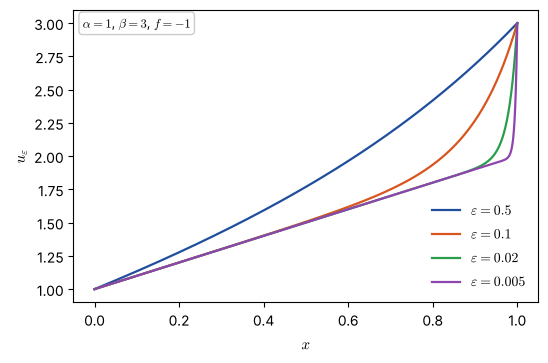

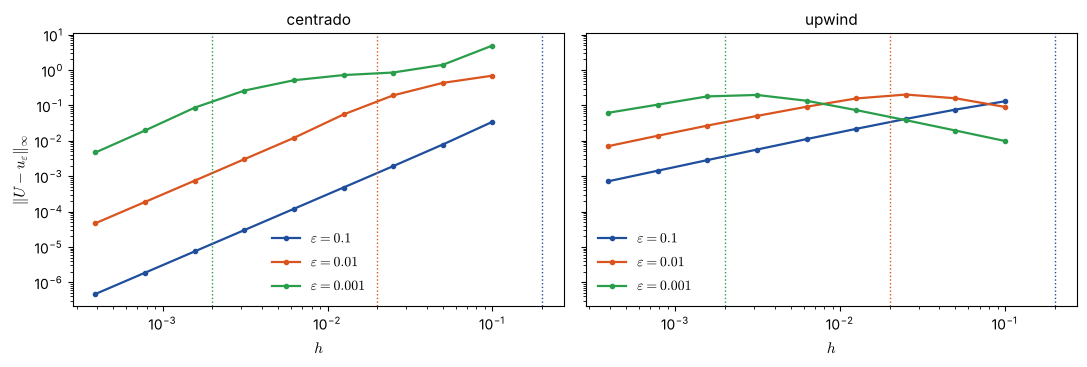

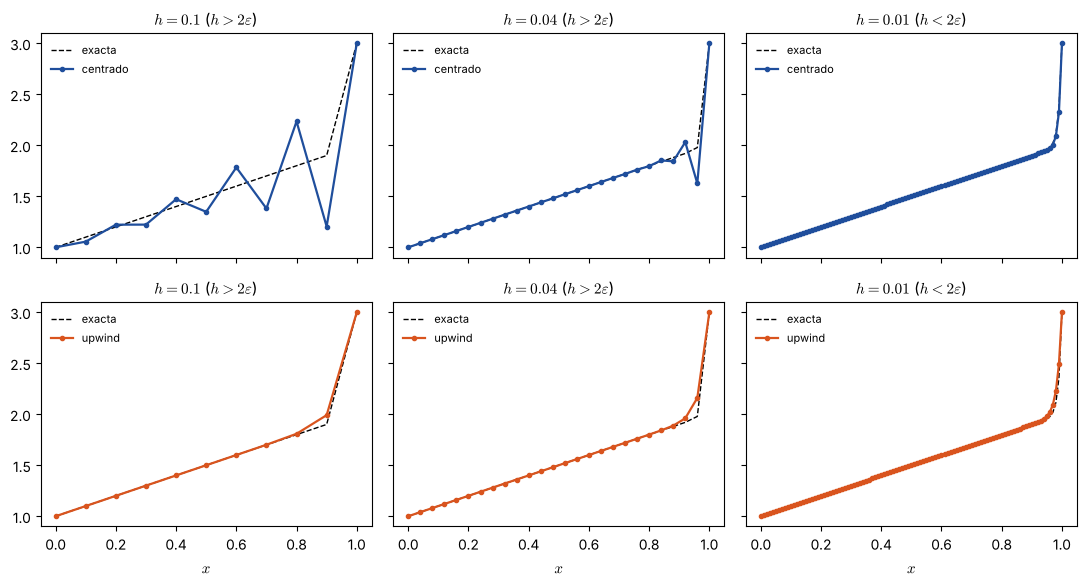

In [11]:
alpha, beta = 1.0, 3.0

def u_exacta(x, eps, alpha=1.0, beta=3.0):
    """Solución exacta de eps u'' - u' = -1 (forma estable, sin desbordes)."""
    return alpha + x + (beta - alpha - 1) * (np.exp((x - 1) / eps) - np.exp(-1 / eps)) / (1 - np.exp(-1 / eps))

def ancho_capa(eps):
    """Distancia a x = 1 a la que u - (alpha + x) cae a la mitad de su valor en x = 1."""
    x = np.linspace(0, 1, 200001)
    d = u_exacta(x, eps) - (alpha + x)
    return 1 - x[np.argmax(d > d[-1] / 2)]       # d es creciente: primer x donde supera la mitad de su valor en x = 1

def tridiag(a, b, c, m):
    """Matriz rala m x m con subdiagonal a, diagonal b y superdiagonal c (escalares)."""
    return sp.diags([a * np.ones(m - 1), b * np.ones(m), c * np.ones(m - 1)], [-1, 0, 1], format="csc")

def resolver_capa(m, eps, esquema="centrado", alpha=1.0, beta=3.0):
    """eps u'' - u' = -1 con m nodos interiores. Devuelve (x, U) en los m+2 nodos (con los extremos)."""
    h = 1 / (m + 1); x = np.linspace(0, 1, m + 2)
    # esténcil de u_x: (cl, cd, cr) multiplican a U_{j-1}, U_j, U_{j+1}
    cl, cd, cr = (-1 / (2 * h), 0.0, 1 / (2 * h)) if esquema == "centrado" else (-1 / h, 1 / h, 0.0)
    sub, dia, sup = eps / h ** 2 - cl, -2 * eps / h ** 2 - cd, eps / h ** 2 - cr
    b = -np.ones(m)
    b[0] -= alpha * sub; b[-1] -= beta * sup
    U = spla.spsolve(tridiag(sub, dia, sup, m), b)
    return x, np.concatenate([[alpha], U, [beta]])

xx = np.linspace(0, 1, 2001)
fig, ax = plt.subplots(figsize=(6, 3.8))
for eps, c in zip([0.5, 0.1, 0.02, 0.005], CICLO):
    ax.plot(xx, u_exacta(xx, eps), color=c, label=rf"$\varepsilon={eps}$")
ax.set_xlabel("$x$"); ax.set_ylabel(r"$u_\varepsilon$"); ax.legend()
estilo.parametros(ax, r"$\alpha=1$, $\beta=3$, $f=-1$", loc="upper left")
for eps in [0.5, 0.1, 0.02, 0.005]:
    print(f"eps = {eps:6.3f}: ancho de la capa {ancho_capa(eps):.5f}   ancho/eps = {ancho_capa(eps) / eps:.3f}")

ms_c = 10 * 2 ** np.arange(0, 9) - 1
epss = [0.1, 0.01, 0.001]
fig2, axs2 = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, esq in zip(axs2, ["centrado", "upwind"]):
    for eps, c in zip(epss, CICLO):
        e = [np.abs(resolver_capa(m, eps, esq)[1] - u_exacta(resolver_capa(m, eps, esq)[0], eps)).max() for m in ms_c]
        ax.loglog(1 / (ms_c + 1), e, "o-", ms=3, color=c, label=rf"$\varepsilon={eps}$")
        ax.axvline(2 * eps, color=c, ls=":", lw=1)
    ax.set_title(esq); ax.set_xlabel("$h$"); ax.legend()
axs2[0].set_ylabel(r"$\|U-u_\varepsilon\|_\infty$")
fig2.tight_layout()

eps = 0.01
fig3, axs3 = plt.subplots(2, 3, figsize=(11, 6), sharex=True, sharey=True)
for j, m in enumerate([9, 24, 99]):
    for i, esq in enumerate(["centrado", "upwind"]):
        x, U = resolver_capa(m, eps, esq)
        ax = axs3[i, j]
        ax.plot(x, u_exacta(x, eps), "k--", lw=1, label="exacta"); ax.plot(x, U, "o-", ms=3, color=CICLO[i], label=esq)
        comp = r"$h>2\varepsilon$" if 1 / (m + 1) > 2 * eps else r"$h<2\varepsilon$"
        ax.set_title(f"$h={1/(m+1):.2g}$ ({comp})"); ax.legend(fontsize=8, loc="upper left")
for ax in axs3[1]:
    ax.set_xlabel("$x$")
fig3.tight_layout()

In [12]:
# Verificación
x_t = np.linspace(0, 1, 11)
assert np.allclose(u_exacta(x_t, 0.5), 1 + x_t + (np.exp(x_t / 0.5) - 1) / (np.exp(2.0) - 1)), "u_exacta"
assert np.all(np.isfinite(u_exacta(x_t, 1e-4))), "u_exacta desborda para eps chico"
assert 0.6 < ancho_capa(0.01) / 0.01 < 0.8, "el ancho de la capa es ~ 0.69 eps"
x, U = resolver_capa(159, 0.1)
assert len(x) == 161 and U[0] == 1 and U[-1] == 3 and np.abs(U - u_exacta(x, 0.1)).max() < 3e-4, "centrado, eps = 0.1"
x, U = resolver_capa(19, 0.01)
assert np.abs(U - u_exacta(x, 0.01)).max() > 0.1 and np.any(np.diff(np.sign(np.diff(U))) != 0), "h > 2 eps: debería oscilar"
x, U = resolver_capa(19, 0.01, "upwind")
assert np.all(np.diff(U) > -1e-12), "upwind: la solución debería ser monótona"
print("capa límite: OK")

capa límite: OK


**Para el docente.** (i) `ancho_capa`: el ancho da $\varepsilon\ln2\approx0.693\,\varepsilon$ (la parte exponencial es $e^{(x-1)/\varepsilon}$ y cae a la mitad en $x=1-\varepsilon\ln2$); (ii) Error típico: usar la fórmula inestable y obtener `nan` para $\varepsilon\le10^{-3}$. (iii) Para $\varepsilon=0.001$ el centrado recién converge a partir de $h<0.002$ ($m\gtrsim 500$): con $m+1$ hasta 2560 se ve el cambio de régimen; el primer $h$ "bueno" para cada $\varepsilon$ es $\approx2\varepsilon$. (iv) Tiempo: 35 minutos.

## 5. Condiciones de Neumann: tres formas de imponer $u'(0)=0$

Ahora $u''=f$ en $(0,1)$ con $u'(0)=0$ y $u(1)=0$. Con $h=1/(m+1)$ y nodos $x_j=jh$, el valor en $x=0$ *es una incógnita*: las incógnitas son $U_0,\dots,U_m$ (con $U_{m+1}=0$). En los nodos $j=1,\dots,m$ vale la ecuación de siempre, $\frac{U_{j-1}-2U_j+U_{j+1}}{h^2}=f(x_j)$ (con $U_{m+1}=0$). Falta una ecuación: la fila $j=0$, que tiene que expresar $u'(0)=0$. Las tres opciones del enunciado:

* **(a) Forward de orden 1:** $\dfrac{U_1-U_0}{h}=0$. Por Taylor, $\frac{u(h)-u(0)}h=u'(0)+\frac h2u''(0)+O(h^2)$: el error de truncamiento es $\frac h2 u''(0)=\frac h2f(0)$, de orden 1 **salvo que $f(0)=0$**.
* **(b) Nodo ficticio:** se agrega un nodo $x_{-1}=-h$ con incógnita $U_{-1}$, dos ecuaciones: la del esquema en $j=0$, $\frac{U_{-1}-2U_0+U_1}{h^2}=f(x_0)$, y la de Neumann centrada $\frac{U_1-U_{-1}}{2h}=0$. Se elimina $U_{-1}=U_1$ y queda $\dfrac{2U_1-2U_0}{h^2}=f(x_0)$. Es de orden 2. Notá que es la opción (a) más la corrección $\frac h2f(0)$: $\frac{U_1-U_0}{h}=\frac h2f(0)$, lo cual explica lo del párrafo anterior.
* **(c) Forward de orden 2:** $\dfrac{-\frac32U_0+2U_1-\frac12U_2}{h}=0$ (es el esquema $\{0,1,2\}$ de la Tarea 1, con el signo cambiado; los pesos $\frac12(-3,4,-1)$). Error $O(h^2)$.

**Sobre escalas.** Al reemplazar una fila hay que decidir por qué se la multiplica: (a) y (c) son ecuaciones sobre $u'$, y (b) sobre $u''$. Da lo mismo para la solución del sistema, pero no para leer el error de truncamiento: para eso hay que mirar la ecuación que efectivamente se resuelve, sobre todo si el sistema mezcla escalas.

**El orden global** de la aproximación es lo que se mide: $e_m=\|U-u\|_\infty$ contra $h$, como en la Tarea 2. Un error de truncamiento $O(h)$ en *una sola fila* no basta para arruinar el orden 2 en general (la fila afecta a la solución a través de la inversa), pero en este problema sí lo hace. Es una de las cosas que vamos a medir.

In [13]:
# Datos y soluciones exactas del problema de Neumann: u'' = f, u'(0) = 0, u(1) = 0
f_sin = lambda x: np.sin(2 * np.pi * x)
u_sin = lambda x: -(1 - x) / (2 * np.pi) - np.sin(2 * np.pi * x) / (4 * np.pi ** 2)
f_cos = lambda x: np.cos(2 * np.pi * x)
u_cos = lambda x: (1 - np.cos(2 * np.pi * x)) / (4 * np.pi ** 2)
xt = np.linspace(0, 1, 5)
print("u'(0) = 0 y u(1) = 0:", (u_sin(1e-6) - u_sin(0)) / 1e-6, u_sin(1.0), (u_cos(1e-6) - u_cos(0)) / 1e-6, u_cos(1.0))

u'(0) = 0 y u(1) = 0: 2.7755575615628914e-11 6.204133161670506e-18 5.000000370872072e-07 0.0


### Tarea 5: Poisson con Neumann: tres discretizaciones

Escribí `poisson_neumann(m, f, variante)` con `variante` en `"a"`, `"b"`, `"c"`, que arma la matriz de $(m+1)\times(m+1)$, resuelve y devuelve `(x, U)` con los nodos $x_0,\dots,x_m$. Con $m+1=10,20,40,\dots,1280$ nodos ($m=9,19,\dots$):

1. Para $f=\sin 2\pi x$ (el del enunciado) calculá $e_m=\|U-u\|_\infty$ para las tres variantes, graficá log-log y estimá los órdenes.
2. Repetí con $f=\cos 2\pi x$ (su solución exacta está en la celda de arriba).

**Qué se espera.** Con $f=\cos2\pi x$: orden 1 para (a) y 2 para (b) y (c). Con $f=\sin2\pi x$ vas a ver algo sorprendente en (a): mirá los números y explicá por qué (pista: ¿cuánto vale $f(0)$, y qué relación tiene esto con las filas de (a) y (b)? Comparalas para este $f$). Recomendación: usá matrices densas (`np.zeros`) y `np.linalg.solve`, con $m\le1300$ alcanza.

f = sin: variante a: orden 2.00


f = sin: variante b: orden 2.00


f = sin: variante c: orden 2.00


f = cos: variante a: orden 1.00


f = cos: variante b: orden 2.00


f = cos: variante c: orden 2.07


con f = sin(2 pi x): max|U_a - U_b| = 1.3322676295501878e-15


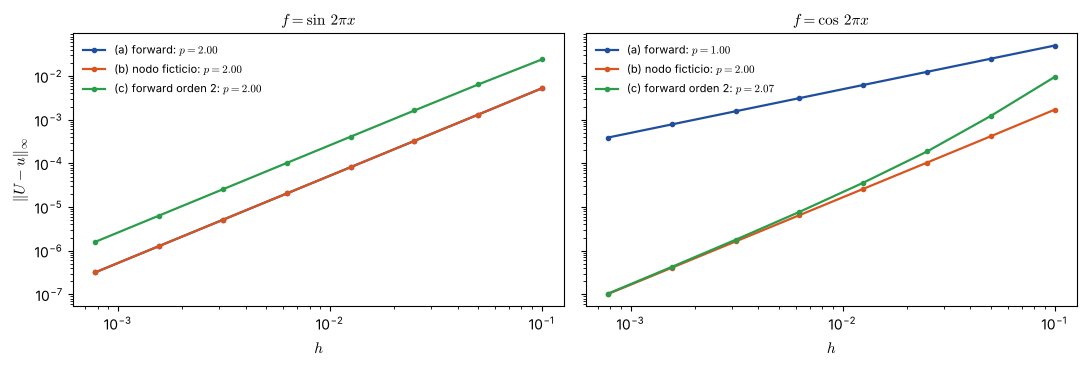

In [14]:
def poisson_neumann(m, f, variante):
    """u'' = f, u'(0) = 0, u(1) = 0. Incógnitas U_0..U_m. Devuelve (x, U)."""
    h = 1 / (m + 1); x = h * np.arange(0, m + 1)
    A = np.zeros((m + 1, m + 1)); b = f(x).astype(float)
    for j in range(1, m + 1):
        A[j, j - 1] = 1 / h ** 2; A[j, j] = -2 / h ** 2
        if j + 1 <= m:
            A[j, j + 1] = 1 / h ** 2
    if variante == "a":                      # (U_1 - U_0)/h = 0
        A[0, 0], A[0, 1], b[0] = -1 / h, 1 / h, 0.0
    elif variante == "b":                    # nodo ficticio: (2 U_1 - 2 U_0)/h^2 = f_0
        A[0, 0], A[0, 1] = -2 / h ** 2, 2 / h ** 2
    elif variante == "c":                    # -(3/2 U_0 - 2 U_1 + 1/2 U_2)/h = 0
        A[0, 0], A[0, 1], A[0, 2], b[0] = -1.5 / h, 2 / h, -0.5 / h, 0.0
    return x, np.linalg.solve(A, b)

ms_n = 10 * 2 ** np.arange(0, 8) - 1
hs_n = 1 / (ms_n + 1)
etiquetas = {"a": "(a) forward", "b": "(b) nodo ficticio", "c": "(c) forward orden 2"}
errN = {}
fig, axs = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, (nombre, fN, uN) in zip(axs, [("sin", f_sin, u_sin), ("cos", f_cos, u_cos)]):
    for c, var in zip(CICLO, "abc"):
        errN[(nombre, var)] = np.array([np.abs(poisson_neumann(m, fN, var)[1] - uN(poisson_neumann(m, fN, var)[0])).max() for m in ms_n])
        p = orden_empirico(hs_n, errN[(nombre, var)], ultimos=4)
        ax.loglog(hs_n, errN[(nombre, var)], "o-", ms=3, color=c, label=f"{etiquetas[var]}: $p={p:.2f}$")
        print(f"f = {nombre}: variante {var}: orden {p:.2f}")
    ax.set_title(rf"$f=\{nombre}\,2\pi x$"); ax.set_xlabel("$h$"); ax.legend(fontsize=8)
axs[0].set_ylabel(r"$\|U-u\|_\infty$")
fig.tight_layout()
_, Ua = poisson_neumann(99, f_sin, "a"); _, Ub = poisson_neumann(99, f_sin, "b")
print("con f = sin(2 pi x): max|U_a - U_b| =", np.abs(Ua - Ub).max())

In [15]:
# Verificación
p = lambda nombre, var: orden_empirico(hs_n, errN[(nombre, var)], ultimos=4)
assert 0.85 < p("cos", "a") < 1.15, "f = cos: (a) es de orden 1"
assert 1.8 < p("cos", "b") < 2.2 and 1.8 < p("cos", "c") < 2.5, "f = cos: (b) y (c) de orden 2"
assert 1.8 < p("sin", "b") < 2.2
print("Neumann: OK")

Neumann: OK


**Para el docente.** *Discrepancia con lo que el enunciado sugiere:* con $f=\sin2\pi x$ se tiene $f(0)=0$, y entonces las filas (a) y (b) son *idénticas* ($\frac{U_1-U_0}{h}=\frac h2f(0)=0$) y las dos dan orden 2 (medido: 2.00 en ambas, error $1.28\times10^{-6}$ con $m=639$). Con $f=\cos2\pi x$, (a) da 1.00 y (b) 2.00. Por eso la consigna pide los dos datos: es el resultado que hay que explicar en la interpretación. (c) da orden 2 en los dos casos, con constante mayor para $f=\sin$ (error $6.4\times10^{-6}$ contra $1.3\times10^{-6}$). Tiempo: 25 minutos.

# Parte B. Evolución en el tiempo

## 6. La ecuación del calor: el esquema explícito y su estabilidad

Para $U_t=\alpha U_{xx}$ en $(0,1)$ con Dirichlet homogéneo usamos la grilla $x_j=jh$, $t_n=nk$ ($h=\Delta x$, $k=\Delta t$) y $u_j^n\approx U(x_j,t_n)$. Diferencia *forward* en el tiempo y *centrada* en el espacio dan el **esquema explícito** (FTCS):
$$\frac{u_j^{n+1}-u_j^n}{k}=\alpha\frac{u_{j+1}^n-2u_j^n+u_{j-1}^n}{h^2}\iff u_j^{n+1}=r\,u_{j-1}^n+(1-2r)\,u_j^n+r\,u_{j+1}^n,\quad r=\frac{\alpha k}{h^2}.$$
(En `imc.numerico` el coeficiente se llama $D$; es el mismo $\alpha$.) Es *explícito* porque cada valor nuevo se calcula directamente de los viejos: sin resolver sistemas.

**Consistencia.** Sea $T_j^n=\frac{U(x_j,t_{n+1})-U(x_j,t_n)}k-\alpha\frac{U(x_{j+1},t_n)-2U(x_j,t_n)+U(x_{j-1},t_n)}{h^2}$ el error de truncamiento (lo que queda al meter la solución *exacta* en el esquema). Por Taylor, $T=\frac k2U_{tt}-\frac{\alpha h^2}{12}U_{xxxx}+\cdots$. Con $r$ fijo, $k=rh^2/\alpha$, así que $T=O(h^2)$. Más aún, como $U_{tt}=\alpha^2U_{xxxx}$, resulta $T=\alpha h^2\bigl(\frac r2-\frac1{12}\bigr)U_{xxxx}+\cdots$, que se anula (queda $O(h^4)$) si $r=\frac16$. **Pero consistencia no alcanza:** el error $e_j^n=U(x_j,t_n)-u_j^n$ cumple
$$e_j^{n+1}=r\,e_{j-1}^n+(1-2r)\,e_j^n+r\,e_{j+1}^n+k\,T_j^n,$$
o sea que el esquema propaga el error anterior y le suma $kT$ en cada paso. Todo depende de si la propagación amplifica o no.

**Estabilidad en norma $\infty$ (si $r\le\frac12$).** Los tres coeficientes $r,\,1-2r,\,r$ son $\ge0$ y suman 1, así que $|e_j^{n+1}|\le\max_i|e_i^n|+k\|T\|$: $E_{n+1}\le E_n+kM$, y por lo tanto $E_n\le nkM=t_nM$. Con $M=O(k+h^2)$ se obtiene convergencia. Si $r>\frac12$ el coeficiente $1-2r$ es negativo y el argumento falla; veamos que la falla es real.

**Estabilidad de von Neumann.** Los modos de Fourier $u_j^n=g^n e^{i\theta j}$ ($\theta=$ frecuencia en la grilla, $\theta\in[0,\pi]$) resuelven el esquema (sin bordes) si
$$g(\theta)=1-2r(1-\cos\theta)=1-4r\sin^2\tfrac\theta2\ \in[\,1-4r,\;1\,].$$
El modo $n$ crece si $|g|>1$. Como $g\le1$ siempre y el mínimo es $1-4r$ (en $\theta=\pi$, el modo "serrucho" $(-1)^j$), hay estabilidad para todo $\theta$ si y sólo si $1-4r\ge-1\iff\boxed{r\le\tfrac12}$. Con $r>\frac12$ el modo serrucho se multiplica por $1-4r<-1$ en cada paso: crece geométricamente y cambia de signo. Cualquier error de redondeo con componente en ese modo termina dominando la solución. Es *exactamente* el fenómeno de Euler explícito con $1+h\lambda<-1$: el sistema $\dot U=\alpha A_hU$ tiene autovalores $-\frac{4\alpha}{h^2}\sin^2\frac{\pi jh}2\in(-\frac{4\alpha}{h^2},0)$ (es **rígido**: $\lambda$ crece como $h^{-2}$) y Euler explícito exige $k\cdot\frac{4\alpha}{h^2}\le 2$, que es $r\le\frac12$.

**Teorema de equivalencia de Lax (sin demostración).** Para un problema lineal bien planteado y un esquema consistente, *estabilidad $\iff$ convergencia*. La consistencia se ve por Taylor y la estabilidad por von Neumann (o por normas): son los dos ingredientes de todo esquema de este laboratorio.

**Costo.** Cada paso cuesta $O(m)$, pero $k\le\frac{h^2}{2\alpha}$: para llegar al tiempo $T$ hacen falta $\ge2\alpha T/h^2$ pasos. Refinar $h$ a la mitad multiplica por **8** el trabajo total ($m$ doble, pasos por 4).

**Para pensar.** (i) Completá la cuenta de $T=O(h^2)$ y del caso $r=1/6$. (ii) El dato inicial $\sin(\pi x)$ es un autovector de $A_h$ (un solo modo). ¿Qué predice von Neumann para su evolución en el esquema explícito, incluso con $r>1/2$? (Lo vas a ver.)

### Tarea 6: El esquema explícito y la condición $r\le1/2$

Escribí `calor_explicito_mio(u0, alpha, h, k, pasos)`: devuelve un array `(pasos+1, len(u0))` con el esquema explícito y Dirichlet homogéneo (`u[n, 0] = u[n, -1] = 0`). Después, con $\alpha=1$, $h=0.05$ (Ejercicio "programita"):

1. **(a)** Dato $u_0=x\chi_{[0,1/2]}+(1-x)\chi_{[1/2,1]}$ (la "carpa"), $k=0.0012$ y $k=0.0013$, al menos 50 pasos. Verificá $r$ en cada caso. Graficá los perfiles en $n=100$ y `max|u|` contra $n$.
2. **(b)** Con $k=0.0013$, los datos $x(1-x)$ y $\sin\pi x$. Corré 900 pasos y graficá `max|u^n|` contra $n$ en escala semilog para los cuatro casos: carpa con $r=0.48$ y con $r=0.52$, $x(1-x)$ y $\sin\pi x$ con $r=0.52$. Anotá el paso en que cada uno supera $\max|u|>1$ (si lo hace).
3. Escribí `factor_amplificacion(theta, r)` ($g(\theta)$), graficalo para $r=0.25,\,0.5,\,0.52$ y calculá numéricamente `r_critico()`: el mayor $r$ tal que $\max_\theta|g|\le1$.
4. Escribí `coef_modo(u0, k)`: el coeficiente del modo discreto $\sin(k\pi x_j)$ en el dato, $c_k=\frac{2}{N}\sum_{j=1}^{N-1}u_0(x_j)\sin(k\pi x_j)$, y calculalo para el modo más inestable ($k=N-1$) en los tres datos.

**Qué se espera.** Con $r=0.48$ la carpa se suaviza y decae; con $r=0.52$ aparece un serrucho que crece y termina explotando. Los tres datos con $r=0.52$ terminan explotando, pero **a tiempos muy distintos**: la carpa y $x(1-x)$ antes de 200 pasos, $\sin\pi x$ mucho después (y casi sin señales antes). El punto 4 explica por qué. `r_critico()` tiene que dar $0.5$.

r para k = 0.0012: 0.480;  para k = 0.0013: 0.520;  r_critico = 0.5000
     carpa, r=0.48: max|u| en n = 50: 0.224, 100: 0.124, 200: 0.0377; supera 1 en n = None
     carpa, r=0.52: max|u| en n = 50: 0.279, 100: 1.79, 200: 1.12e+03; supera 1 en n = 90
    x(1-x), r=0.52: max|u| en n = 50: 0.135, 100: 0.0768, 200: 4.39; supera 1 en n = 177
 sin(pi x), r=0.52: max|u| en n = 50: 0.525, 100: 0.276, 200: 0.076; supera 1 en n = 569
coeficiente del modo k = N-1 de      carpa: -2.52e-03
coeficiente del modo k = N-1 de     x(1-x): +9.90e-06
coeficiente del modo k = N-1 de  sin(pi x): -9.85e-17


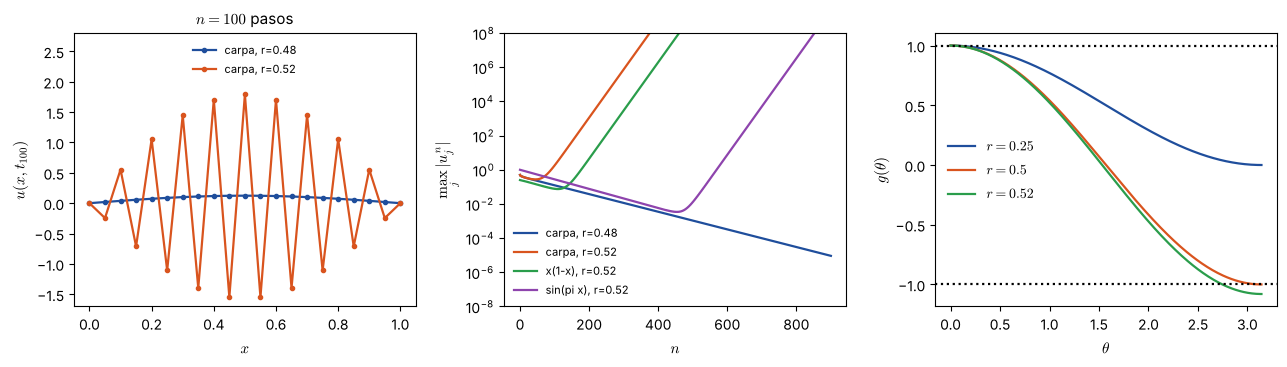

In [16]:
def calor_explicito_mio(u0, alpha, h, k, pasos):
    """Esquema explícito para u_t = alpha u_xx con Dirichlet homogéneo. Devuelve u de forma (pasos+1, len(u0))."""
    r = alpha * k / h ** 2
    u = np.zeros((pasos + 1, len(u0))); u[0] = u0
    for n in range(pasos):
        u[n + 1, 1:-1] = r * u[n, :-2] + (1 - 2 * r) * u[n, 1:-1] + r * u[n, 2:]
    return u

alpha, h = 1.0, 0.05
x = np.arange(0, 1 + h / 2, h); N = len(x) - 1
carpa = np.where(x <= 0.5, x, 1 - x)

def factor_amplificacion(theta, r):
    return 1 - 4 * r * np.sin(theta / 2) ** 2

def r_critico():
    """Mayor r (en una grilla fina) con max_theta |g| <= 1."""
    th = np.linspace(0, np.pi, 2001)
    rs = np.linspace(0.3, 0.7, 4001)
    ok = [np.abs(factor_amplificacion(th, r)).max() <= 1 + 1e-12 for r in rs]
    return rs[np.max(np.nonzero(ok))]

def coef_modo(u0, k):
    """Coeficiente del modo discreto sin(k pi x_j) en el dato u0 (nodos x_0..x_N, N = len(u0)-1)."""
    N = len(u0) - 1; j = np.arange(1, N)
    return 2 / N * np.sum(u0[1:-1] * np.sin(k * np.pi * j / N))

k1, k2 = 0.0012, 0.0013
print(f"r para k = {k1}: {alpha * k1 / h**2:.3f};  para k = {k2}: {alpha * k2 / h**2:.3f};  r_critico = {r_critico():.4f}")
datos_ic = {"carpa": carpa, "x(1-x)": x * (1 - x), "sin(pi x)": np.sin(np.pi * x)}
casos = [("carpa, r=0.48", carpa, k1), ("carpa, r=0.52", carpa, k2), ("x(1-x), r=0.52", x * (1 - x), k2), ("sin(pi x), r=0.52", np.sin(np.pi * x), k2)]
sols = {nombre: calor_explicito_mio(u0, alpha, h, k, 900) for nombre, u0, k in casos}
for nombre, u in sols.items():
    m = np.abs(u).max(axis=1)
    n_exp = np.argmax(m > 1) if np.any(m > 1) else None
    print(f"{nombre:>18s}: max|u| en n = 50: {m[50]:.3g}, 100: {m[100]:.3g}, 200: {m[200]:.3g}; supera 1 en n = {n_exp}")
for nombre, u0 in datos_ic.items():
    print(f"coeficiente del modo k = N-1 de {nombre:>10s}: {coef_modo(u0, N - 1):+.2e}")

fig, axs = plt.subplots(1, 3, figsize=(13, 3.8))
for (nombre, u0, k), c in zip(casos[:2], CICLO):
    axs[0].plot(x, sols[nombre][100], "o-", ms=3, color=c, label=nombre)
axs[0].set_xlabel("$x$"); axs[0].set_ylabel("$u(x, t_{100})$"); axs[0].set_ylim(-1.7, 2.8); axs[0].legend(loc="upper center", fontsize=8); axs[0].set_title("$n=100$ pasos")
for (nombre, u0, k), c in zip(casos, CICLO):
    axs[1].semilogy(np.abs(sols[nombre]).max(axis=1) + 1e-300, color=c, label=nombre)
axs[1].set_ylim(1e-8, 1e8); axs[1].set_xlabel("$n$"); axs[1].set_ylabel(r"$\max_j|u_j^n|$"); axs[1].legend(fontsize=8)
th = np.linspace(0, np.pi, 300)
for r, c in zip([0.25, 0.5, 0.52], CICLO):
    axs[2].plot(th, factor_amplificacion(th, r), color=c, label=f"$r={r}$")
axs[2].axhline(-1, color="k", ls=":"); axs[2].axhline(1, color="k", ls=":")
axs[2].set_xlabel(r"$\theta$"); axs[2].set_ylabel(r"$g(\theta)$"); axs[2].legend()
fig.tight_layout()

In [17]:
# Verificación
h_v = 0.05; xv = np.arange(0, 1 + h_v / 2, h_v); uv = np.where(xv <= 0.5, xv, 1 - xv)
for k_v in (0.0012, 0.0013):
    ref = numerico.calor_explicito(uv, 1.0, h_v, k_v, 80)
    assert np.allclose(calor_explicito_mio(uv, 1.0, h_v, k_v, 80), ref), "no coincide con imc.numerico.calor_explicito"
assert abs(r_critico() - 0.5) < 2e-3, "el r crítico es 1/2"
assert abs(coef_modo(np.sin(np.pi * xv), 1) - 1) < 1e-12 and abs(coef_modo(np.sin(np.pi * xv), 19)) < 1e-12
u_c = calor_explicito_mio(uv, 1.0, h_v, 0.0012, 300); u_i = calor_explicito_mio(uv, 1.0, h_v, 0.0013, 300)
assert np.abs(u_c).max() <= 0.5 and np.abs(u_i[-1]).max() > 1, "r = 0.48 debería decaer y r = 0.52 explotar"
print("calor explícito: OK")

calor explícito: OK


**Para el docente.** *Discrepancia con lo que insinúa el enunciado* (Ejercicio "programita", (b)): el texto pregunta "¿qué ocurre con (i) para 100 pasos? ¿y con (ii)?" como si a los 100 pasos ya hubiera diferencias. Medido con $k=0.0013$: a los 100 pasos ni $x(1-x)$ ($\max|u|=0.077$) ni $\sin\pi x$ ($0.28$) muestran nada; $x(1-x)$ supera 1 en $n\approx177$ (la carpa en $n\approx90$), y $\sin\pi x$ recién en $n\approx570$. Eso hay que mostrarlo corriendo más pasos (la consigna pide 900). Explicación de (ii): $\sin\pi x_j$ es autovector de $A_h$ y su coeficiente en el modo $k=N-1$ es $\sim10^{-17}$ (redondeo); el modo inestable crece como $|1-4r\sin^2(19\pi/40)|^n\approx1.08^n$ y necesita $\ln(10^{16})/\ln1.08\approx480$ pasos para hacerse visible (el modo fundamental decae mientras tanto). La carpa tiene componente $2.5\times10^{-3}$ en ese modo y $x(1-x)$ $10^{-5}$. Tiempo: 30 minutos.

## 7. Error global del explícito: orden, tiempo y el caso $r=1/6$

Ya sabemos que con $r\le\frac12$ el esquema converge. Ahora medimos *cuánto*. Necesitamos soluciones exactas del problema con Dirichlet homogéneo en $(0,1)$ y $\alpha=1$:

* dato $\sin\pi x$: $U(x,t)=e^{-\pi^2t}\sin\pi x$;
* dato $x(1-x)$: $U(x,t)=\sum_{k\ \text{impar}}\dfrac{8}{k^3\pi^3}\,e^{-k^2\pi^2t}\sin k\pi x$ (serie de senos de $x(1-x)$).

**El error contra el tiempo.** Con $E_n=\max_j|e_j^n|$ el argumento de estabilidad da $E_n\le t_nM$, con $M=\max|T|=O(h^2)$ para $r$ fijo: una cota que *crece* con el tiempo. Pero la solución del calor decae y *olvida* los errores que tienen componentes rápidas: el error real crece al principio y baja después. La cota es correcta pero pesimista (Nota del enunciado).

**El orden en $h$.** Con $r$ fijo, $k=rh^2/\alpha$, se espera $E=O(h^2)$; con $r=\frac16$, gracias a la cancelación del término principal, $E=O(h^4)$. Para medirlo se corre hasta un tiempo $T$ fijo ($T=0.1$) con $h=1/N$, $N=10,20,40,80$: el número de pasos es $n=\mathrm{round}(T/k)$ y el error se compara con la solución exacta en el instante $nk$ (que puede diferir un poco de $T$).

**Consistente e inestable no converge.** Con $r=0.52>\frac12$ el esquema es consistente, pero no estable: el error *no* baja al refinar $h$ (con $N$ grande explota). Es la ilustración concreta del teorema de Lax.

### Tarea 7: Error global del explícito contra el tiempo y contra $h$

Escribí `error_vs_tiempo(u0f, exacta, N, r, T)`, que corre `calor_explicito_mio` con $h=1/N$, $k=rh^2$ ($\alpha=1$) hasta $t\approx T$ y devuelve `(t, E)` con $E_n=\max_j|u_j^n-U(x_j,t_n)|$, y `error_final(u0f, exacta, N, r, T)` que devuelve $E_{n_T}$ en el último paso. Las soluciones exactas `u_sin(x, t)` y `u_par(x, t)` (serie truncada a $k\le2001$) están dadas abajo.

1. Con $r=0.5$ y $N=10,20,40$, graficá $E_n$ contra $t$ (semilog) hasta $T=1$, para los dos datos. ¿Cuándo es máximo el error? ¿Cómo se compara con la cota $E_n\le t\,M$?
2. Con dato $\sin\pi x$ y $T=0.1$, estimá el orden de $E$ en $h$ para $r=0.5$, $r=0.4$ y $r=1/6$ (log-log, $N=10,20,40,80$).
3. Agregá $r=0.52$ con el mismo $T$. ¿Qué pasa con $E$ al refinar?

**Qué se espera.** Órdenes 2, 2 y **4**. Para $r=0.52$ el error baja entre $N=10$ y $20$ pero explota para $N=80$. En el punto 1 el error crece al principio (máximo alrededor de $t\approx0.1$) y después decae con el tiempo, muy por debajo de la cota $tM$.

$\sin\pi x$: N = 10: E máximo 6.16e-03 en t = 0.100; E(T=1) = 7.9e-06


$x(1-x)$: N = 10: E máximo 1.65e-03 en t = 0.095; E(T=1) = 2.0e-06


r = 0.500: errores [6.16e-03 1.52e-03 3.79e-04 9.46e-05]
r = 0.400: errores [4.29e-03 1.06e-03 2.65e-04 6.62e-05]
r = 0.167: errores [6.69e-06 4.16e-07 2.59e-08 1.62e-09]


r = 0.520: errores [6.54e-03 1.61e-03 4.01e-04 3.87e+23]


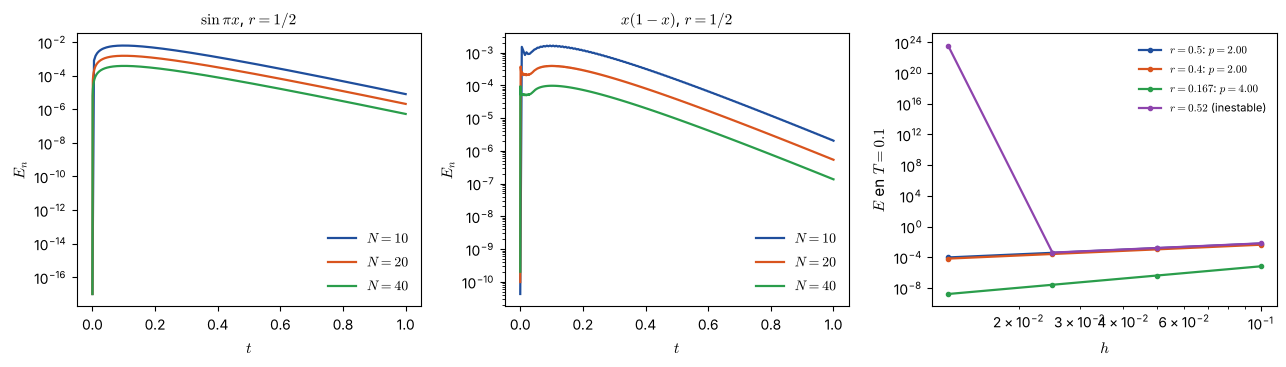

In [18]:
u_sin = lambda x, t: np.exp(-np.pi ** 2 * t) * np.sin(np.pi * x)
def u_par(x, t, K=2001):
    """Solución con dato x(1-x): serie de senos (k impar) truncada."""
    k = np.arange(1, K + 1, 2)[:, None]
    return (8 / (k ** 3 * np.pi ** 3) * np.exp(-k ** 2 * np.pi ** 2 * t) * np.sin(k * np.pi * x[None, :])).sum(axis=0)

def error_vs_tiempo(u0f, exacta, N, r, T):
    """(t, E): E_n = max_j |u_j^n - U(x_j, t_n)|, con h = 1/N, k = r h^2, hasta t ~ T."""
    h = 1 / N; k = r * h ** 2; n = int(round(T / k)); x = np.arange(N + 1) * h
    u = calor_explicito_mio(u0f(x), 1.0, h, k, n)
    t = k * np.arange(n + 1)
    E = np.array([np.abs(u[i] - exacta(x, t[i])).max() for i in range(n + 1)])
    return t, E

def error_final(u0f, exacta, N, r, T):
    return error_vs_tiempo(u0f, exacta, N, r, T)[1][-1]

datos_e = [("$\\sin\\pi x$", lambda x: np.sin(np.pi * x), u_sin), ("$x(1-x)$", lambda x: x * (1 - x), u_par)]
fig, axs = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, (nombre, u0f, ex) in zip(axs[:2], datos_e):
    for N, c in zip([10, 20, 40], CICLO):
        t, E = error_vs_tiempo(u0f, ex, N, 0.5, 1.0)
        ax.semilogy(t, E + 1e-17, color=c, label=f"$N={N}$")
        if N == 10:
            print(f"{nombre}: N = 10: E máximo {E.max():.2e} en t = {t[np.argmax(E)]:.3f}; E(T=1) = {E[-1]:.1e}")
    ax.set_xlabel("$t$"); ax.set_ylabel("$E_n$"); ax.set_title(nombre + r", $r=1/2$"); ax.legend()
Ns_e = np.array([10, 20, 40, 80]); hs_e = 1 / Ns_e
errs_e = {}
for r, c in zip([0.5, 0.4, 1 / 6, 0.52], CICLO):
    errs_e[r] = np.array([error_final(datos_e[0][1], u_sin, N, r, 0.1) for N in Ns_e])
    lbl = f"$r={r:.3g}$" + (f": $p={orden_empirico(hs_e, errs_e[r], 3):.2f}$" if r <= 0.5 else " (inestable)")
    axs[2].loglog(hs_e, errs_e[r], "o-", ms=3, color=c, label=lbl)
    print(f"r = {r:.3f}: errores {np.array2string(errs_e[r], precision=2)}")
axs[2].set_xlabel("$h$"); axs[2].set_ylabel(r"$E$ en $T=0.1$"); axs[2].legend(fontsize=8)
fig.tight_layout()

In [19]:
# Verificación
p = lambda r: orden_empirico(hs_e, errs_e[r], ultimos=3)
assert 1.8 < p(0.5) < 2.2 and 1.8 < p(0.4) < 2.2, "r fijo: orden 2"
assert 3.6 < p(1 / 6) < 4.4, "r = 1/6: orden 4"
assert errs_e[0.52][-1] > 1 > errs_e[0.52][0], "r = 0.52: el error debería explotar al refinar"
print("orden del explícito: OK")

orden del explícito: OK


## 8. El esquema implícito (Euler hacia atrás)

La cura para la restricción $r\le\frac12$ es la misma que en EDOs: evaluar el operador espacial en el tiempo *nuevo*,
$$\frac{u_j^{n+1}-u_j^n}{k}=\alpha\frac{u_{j+1}^{n+1}-2u_j^{n+1}+u_{j-1}^{n+1}}{h^2}\iff -r\,u_{j-1}^{n+1}+(1+2r)\,u_j^{n+1}-r\,u_{j+1}^{n+1}=u_j^n.$$
Cada paso exige resolver un sistema **tridiagonal** $(I-rA_h\,h^2)u^{n+1}=u^n$ (con $A_h$ el Laplaciano de la Tarea 3; con datos de borde nulos no hay términos extra). La matriz es la misma en todos los pasos, y es *estrictamente diagonal dominante*.

**Estabilidad (von Neumann).** Con $u_j^n=g^ne^{i\theta j}$: $g(\theta)=\dfrac{1}{1+4r\sin^2(\theta/2)}\in(0,1]$ para **todo** $r>0$. Es incondicionalmente estable, y además $g>0$: los modos no cambian de signo (no hay serrucho), como pasaba con Euler implícito en la ecuación rígida.

**Consistencia.** El error de truncamiento es $-\frac k2U_{tt}-\frac{\alpha h^2}{12}U_{xxxx}+\cdots=O(k+h^2)$: **orden 1 en el tiempo**, 2 en el espacio. Por Lax converge para todo $r$. Ahora $k$ se elige por *precisión* y no por estabilidad; pero como el error temporal es $O(k)$, agrandar $k$ a $\gg h^2$ degrada el error global a $O(k)$: la estabilidad incondicional no regala precisión.

**Costo.** Resolver el tridiagonal con `solve_banded` cuesta $O(m)$ por paso: el mismo orden que el explícito. `imc.numerico.calor_implicito` es didáctico: usa `np.linalg.solve` con una matriz *densa* en cada paso ($O(m^3)$ por paso). Vas a medir la diferencia.

### Tarea 8: Calor implícito con solve_banded

Escribí `calor_implicito_mio(u0, alpha, h, k, pasos)` con `solve_banded` (armá las diagonales una sola vez, fuera del lazo). Después:

1. Con $h=0.05$ y la carpa, corré $k=0.0013$ ($r=0.52$), $k=0.05$ ($r=20$) y $k=0.5$ ($r=200$), 30 pasos cada uno. Graficá los perfiles. Comprobá que no explota y que no aparecen valores negativos (ni serrucho).
2. Medí el orden del error (dato $\sin\pi x$, $T=0.1$, $N=10,20,\dots,160$) con $r=0.5$, $r=10$ y con $k=h$.
3. Tiempos: `numerico.calor_implicito` contra `calor_implicito_mio`, con 50 pasos, $N=200,400,800$ y $k=10h^2$.

**Qué se espera.** Estabilidad para todos los $r$ probados, sin oscilaciones. Órdenes: 2 para $r$ fijo (porque $k=rh^2$, o sea $O(k+h^2)=O(h^2)$) y **1** para $k=h$ (domina el error temporal). En los tiempos, la de `solve_banded` casi constante y la densa creciendo varias veces por cada duplicación de $N$ (entre 4 y 8).

k = 0.0013: min u = 0.00e+00, max|u| en n = 30: 2.791e-01
k = 0.05: min u = 0.00e+00, max|u| en n = 30: 2.463e-06
k = 0.5: min u = 0.00e+00, max|u| en n = 30: 2.684e-24


N = 200: solve_banded     9.5 ms, np.linalg.solve denso (imc)   9856.9 ms, cociente 1032.7


N = 400: solve_banded     1.6 ms, np.linalg.solve denso (imc)   5093.3 ms, cociente 3121.8


N = 800: solve_banded     2.1 ms, np.linalg.solve denso (imc)  11430.0 ms, cociente 5419.5


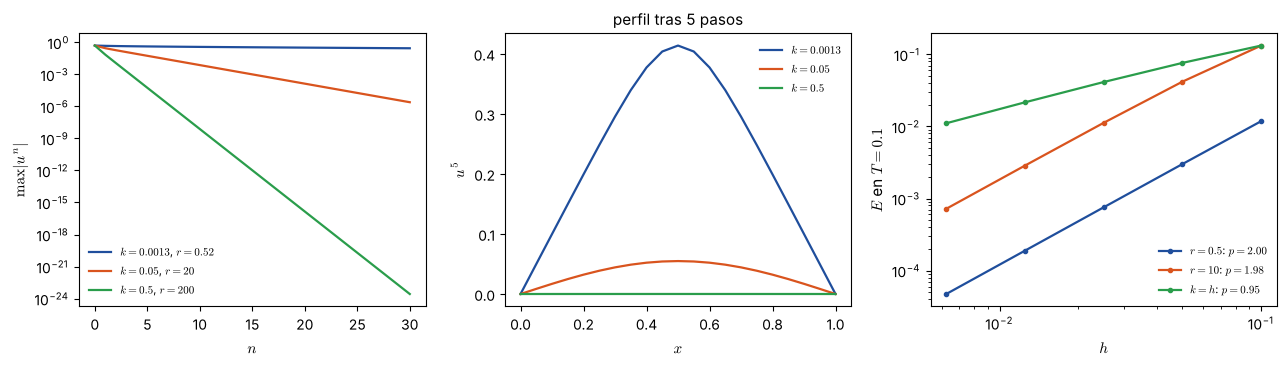

In [20]:
def calor_implicito_mio(u0, alpha, h, k, pasos):
    """Euler hacia atrás para u_t = alpha u_xx con Dirichlet homogéneo. Devuelve u de forma (pasos+1, len(u0))."""
    r = alpha * k / h ** 2
    m = len(u0) - 2
    ab = np.zeros((3, m)); ab[0, 1:] = -r; ab[1] = 1 + 2 * r; ab[2, :-1] = -r
    u = np.zeros((pasos + 1, len(u0))); u[0] = u0
    for n in range(pasos):
        u[n + 1, 1:-1] = solve_banded((1, 1), ab, u[n, 1:-1])
    return u

h = 0.05; x = np.arange(0, 1 + h / 2, h); carpa = np.where(x <= 0.5, x, 1 - x)
fig, axs = plt.subplots(1, 3, figsize=(13, 3.8))
for k_, c in zip([0.0013, 0.05, 0.5], CICLO):
    u = calor_implicito_mio(carpa, 1.0, h, k_, 30)
    axs[0].semilogy(np.abs(u).max(axis=1), color=c, label=f"$k={k_}$, $r={k_ / h**2:.3g}$")
    print(f"k = {k_}: min u = {u.min():.2e}, max|u| en n = 30: {np.abs(u[-1]).max():.3e}")
    axs[1].plot(x, u[5], color=c, label=f"$k={k_}$")
axs[0].set_xlabel("$n$"); axs[0].set_ylabel(r"$\max|u^n|$"); axs[0].legend(fontsize=8)
axs[1].set_xlabel("$x$"); axs[1].set_ylabel("$u^5$"); axs[1].legend(fontsize=8); axs[1].set_title("perfil tras 5 pasos")

Ns8 = np.array([10, 20, 40, 80, 160]); hs8 = 1 / Ns8
def err_imp(N, k_de_h):
    hh = 1 / N; k_ = k_de_h(hh); n = int(round(0.1 / k_)); k_ = 0.1 / n
    xx = np.arange(N + 1) * hh
    u = calor_implicito_mio(np.sin(np.pi * xx), 1.0, hh, k_, n)
    return np.abs(u[-1] - u_sin(xx, 0.1)).max()
errs8 = {}
for nombre, fk, c in [("$r=0.5$", lambda hh: 0.5 * hh ** 2, CICLO[0]), ("$r=10$", lambda hh: 10 * hh ** 2, CICLO[1]), ("$k=h$", lambda hh: hh, CICLO[2])]:
    errs8[nombre] = np.array([err_imp(N, fk) for N in Ns8])
    axs[2].loglog(hs8, errs8[nombre], "o-", ms=3, color=c, label=f"{nombre}: $p={orden_empirico(hs8, errs8[nombre], 3):.2f}$")
axs[2].set_xlabel("$h$"); axs[2].set_ylabel(r"$E$ en $T=0.1$"); axs[2].legend(fontsize=8)
fig.tight_layout()

for N in [200, 400, 800]:
    hh = 1 / N; xx = np.arange(N + 1) * hh; u0 = np.sin(np.pi * xx)
    t0 = time.time(); calor_implicito_mio(u0, 1.0, hh, 10 * hh ** 2, 50); t_b = time.time() - t0
    t0 = time.time(); numerico.calor_implicito(u0, 1.0, hh, 10 * hh ** 2, 50); t_d = time.time() - t0
    print(f"N = {N}: solve_banded {t_b * 1e3:7.1f} ms, np.linalg.solve denso (imc) {t_d * 1e3:8.1f} ms, cociente {t_d / t_b:6.1f}")

In [21]:
# Verificación
h_v = 0.05; xv = np.arange(0, 1 + h_v / 2, h_v); uv = np.where(xv <= 0.5, xv, 1 - xv)
for k_v in (0.0013, 0.05):
    assert np.allclose(calor_implicito_mio(uv, 1.0, h_v, k_v, 40), numerico.calor_implicito(uv, 1.0, h_v, k_v, 40)), "no coincide con imc.numerico.calor_implicito"
u_g = calor_implicito_mio(uv, 1.0, h_v, 0.5, 30)
assert u_g.min() >= -1e-14 and np.all(np.diff(np.abs(u_g).max(axis=1)) <= 1e-14), "r = 200: debería decaer sin oscilar"
pp = lambda nombre: orden_empirico(hs8, errs8[nombre], ultimos=3)
assert 1.8 < pp("$r=0.5$") < 2.2 and 1.8 < pp("$r=10$") < 2.2 and 0.8 < pp("$k=h$") < 1.2, "órdenes 2, 2 y 1"
print("calor implícito: OK")

calor implícito: OK


### Lectura: Crank–Nicolson

El error temporal $O(k)$ del implícito se arregla promediando explícito e implícito ($\theta=\frac12$): $\dfrac{u^{n+1}-u^n}{k}=\dfrac\alpha2\bigl(D_2u^n+D_2u^{n+1}\bigr)$ ($D_2$ = segunda diferencia centrada). Es el esquema de **Crank–Nicolson**: error $O(k^2+h^2)$, con $g(\theta)=\dfrac{1-2r\sin^2(\theta/2)}{1+2r\sin^2(\theta/2)}$, de módulo $\le1$ para todo $r$ (incondicionalmente estable), y un solo sistema tridiagonal por paso. Es el estándar de la práctica: con $k\sim h$ se logra el mismo orden 2 que el explícito con $r=\frac12$ ($k\sim h^2$), con $\sim1/h$ pasos en lugar de $1/h^2$. Ojo: cuando $r$ es grande $g\to-1$ para los modos altos (cambian de signo en cada paso, aunque no crecen): con datos no suaves, las oscilaciones tardan mucho en amortiguarse. Sólo lo leemos y lo corremos: no hay que programarlo.

In [22]:
def calor_cn(u0, alpha, h, k, pasos):
    """Crank–Nicolson para u_t = alpha u_xx con Dirichlet homogéneo (ya escrito: para leer)."""
    r = alpha * k / h ** 2; m = len(u0) - 2
    ab = np.zeros((3, m)); ab[0, 1:] = -r / 2; ab[1] = 1 + r; ab[2, :-1] = -r / 2
    u = np.zeros((pasos + 1, len(u0))); u[0] = u0
    for n in range(pasos):
        v = u[n, 1:-1]
        rhs = (1 - r) * v; rhs[1:] += r / 2 * v[:-1]; rhs[:-1] += r / 2 * v[1:]
        u[n + 1, 1:-1] = solve_banded((1, 1), ab, rhs)
    return u

print("error en T = 0.1 (dato sen(pi x)), k = h:   N :  pasos   implícito     Crank-Nicolson")
for N in [10, 20, 40, 80, 160]:
    hh = 1 / N; n = int(round(0.1 / hh)); xx = np.arange(N + 1) * hh; u0 = np.sin(np.pi * xx)
    e_i = np.abs(calor_implicito_mio(u0, 1.0, hh, 0.1 / n, n)[-1] - np.exp(-np.pi ** 2 * 0.1) * u0).max()
    e_c = np.abs(calor_cn(u0, 1.0, hh, 0.1 / n, n)[-1] - np.exp(-np.pi ** 2 * 0.1) * u0).max()
    print(f"{N:32d} : {n:5d}   {e_i:.2e}   {e_c:.2e}")

error en T = 0.1 (dato sen(pi x)), k = h:   N :  pasos   implícito     Crank-Nicolson
                              10 :     1   1.33e-01   2.99e-02
                              20 :     2   7.62e-02   6.88e-03
                              40 :     4   4.14e-02   1.69e-03
                              80 :     8   2.16e-02   4.20e-04
                             160 :    16   1.11e-02   1.05e-04


## 9. La ecuación de ondas: leapfrog y la condición CFL

Para $u_{tt}=c^2u_{xx}$ en $(0,L)$ con extremos fijos, reemplazamos las dos derivadas segundas por diferencias centradas, $u_{tt}\approx\frac{u_j^{n+1}-2u_j^n+u_j^{n-1}}{k^2}$ y $u_{xx}\approx\frac{u_{j+1}^n-2u_j^n+u_{j-1}^n}{h^2}$ ($h=\Delta x$, $k=\Delta t$):
$$u_j^{n+1}=2u_j^n-u_j^{n-1}+r^2\bigl(u_{j+1}^n-2u_j^n+u_{j-1}^n\bigr),\qquad r=\frac{c\,k}{h}.$$
Es explícito, de **tres niveles** de tiempo ("salta la rana": $u^{n+1}$ se calcula de $u^n$ y $u^{n-1}$), con error de truncamiento $O(k^2+h^2)$.

**El primer paso.** La recurrencia necesita $u^0$ y $u^1$, pero los datos son $u(x,0)=g$ y $u_t(x,0)=\eta$ (le decimos $\eta$ a la velocidad inicial para no confundirla con el paso $h$; en el enunciado es $h$). Por Taylor: $u(x,k)=g+k\,\eta+\frac{k^2}{2}u_{tt}(x,0)+\cdots$ y $u_{tt}=c^2u_{xx}=c^2g''$, de donde
$$u_j^1=g_j+k\,\eta_j+\frac{r^2}{2}\bigl(g_{j+1}-2g_j+g_{j-1}\bigr).$$
**Error típico:** usar $u^1=g+k\eta$ (Euler en el primer paso). Parece inocente, pero deja un error $O(k^2)$ en $u^1$, o sea $O(k)$ en la *velocidad* inicial, y el esquema, que no amortigua nada, lo arrastra: el orden global cae de 2 a **1**. Lo vas a medir.

**Condición CFL (Courant–Friedrichs–Lewy).** El valor $u_j^{n}$ depende de $u_{j-1}^{n-1},u_j^{n-1},u_{j+1}^{n-1}$, y así hacia atrás: el **dominio de dependencia numérico** de $(x_j,t_n)$ es $[x_j-nh,\,x_j+nh]$, es decir, $\pm h$ por paso. El de la ecuación (d'Alembert) es $[x_j-ct_n,\,x_j+ct_n]=[x_j-c\,nk,\,x_j+c\,nk]$, o sea $\pm ck=\pm rh$ por paso. Si $r>1$, la solución de la ecuación depende de datos que el esquema *ni siquiera mira*: podés cambiarlos y la solución numérica no se entera, aunque la exacta cambia. No hay forma de que converja. La condición **necesaria** es
$$\boxed{r=\frac{ck}{h}\le1}\qquad(\text{el esquema tiene que "ver" al menos lo que ve la ecuación}).$$
Aquí también es suficiente: von Neumann con $u_j^n=g^ne^{i\theta j}$ da $g^2-2\bigl(1-2r^2\sin^2\frac\theta2\bigr)g+1=0$, con dos raíces de módulo 1 si $r\le1$ y una de módulo $>1$ (para $\theta=\pi$) si $r>1$. Consecuencias que se observan: para $r<1$ el esquema es *disperso* (las ondas cortas viajan más lento que $c$: aparecen ondulaciones detrás de los frentes), y para $r=1$ es **exacto** en los nodos (es la fórmula de d'Alembert discreta: los datos simplemente se trasladan un nodo por paso).

In [23]:
# Cuerda pulsada: L = c = 1, g = triángulo de altura a = 1 con vértice en x0 = L/5, eta = 0
L, c, x0, a = 1.0, 1.0, 0.2, 1.0

def serie_pulsada(x, t, K=2000):
    """Solución en serie de la cuerda pulsada (coeficientes A_k del ejercicio de la cuerda pulsada)."""
    k = np.arange(1, K + 1)[:, None]
    A = 2 * a * L ** 2 / (np.pi ** 2 * x0 * (L - x0)) * np.sin(k * np.pi * x0 / L) / k ** 2
    return (A * np.cos(c * k * np.pi * t / L) * np.sin(k * np.pi * x[None, :] / L)).sum(axis=0)

def dalembert_pulsada(x, t):
    """Solución exacta por d'Alembert con la extensión impar 2L-periódica del triángulo (para eta = 0)."""
    g_tri = lambda s: np.where(s <= x0, a * s / x0, a * (L - s) / (L - x0))
    def g_ext(s):
        s = np.mod(s, 2 * L)
        return np.where(s <= L, g_tri(s), -g_tri(2 * L - s))
    return 0.5 * (g_ext(x - c * t) + g_ext(x + c * t))

xt = np.linspace(0, 1, 401)
print("serie contra d'Alembert (t = 0.7): max |diferencia| =", np.abs(serie_pulsada(xt, 0.7) - dalembert_pulsada(xt, 0.7)).max())

serie contra d'Alembert (t = 0.7): max |diferencia| = 0.0001583143092046546


### Tarea 9: Leapfrog: implementación, orden y CFL

Escribí `leapfrog_mio(g, eta, c, dx, dt, pasos, primer_paso="taylor")` con extremos fijos: devuelve `(pasos+1, len(g))`. La opción `primer_paso="ingenuo"` usa $u^1=g+k\eta$.

1. **Orden.** Con $g=\sin\pi x$, $\eta=0$ (solución exacta $\cos(\pi ct)\sin\pi x$), $L=c=1$, $r=0.5$ y $N=20,40,80,160$, medí el error máximo en $t=0.3$ con las dos formas del primer paso. (*No uses $t=1$*: allí $\cos\pi t$ es estacionaria y el error de fase aparece al cuadrado, dando orden 4 espurio.)
2. **Cuerda pulsada.** Con $N=200$ ($\Delta x=1/200$, $x_0$ es un nodo) simulá hasta $t=0.7$ con $r=0.5$, $r=1$ y $r=1.05$. Comparalo con `serie_pulsada` (en una tabla: error máximo en $t=0.3$ y $0.7$, y `max|u|`) y graficá los tres perfiles en $t=0.7$ (para $r=1.05$, en el primer paso donde $\max|u|>3$). ¿Qué se observa en cada caso?
3. **Dominios de dependencia.** Con $g=\delta_{j_0}$ (un uno en un nodo central, $N=400$, $j_0=200$), $\eta=0$, y $r=0.5$, $1$, $1.05$, medí el semiancho $s_n$ del soporte de $u^n$ (mayor $|j-j_0|$ con $|u_j^n|>0$) para $n=20,50,100$, y compará con $n$ (numérico) y con $rn$ (donde está el frente de la ecuación, en nodos).

**Qué se espera.** (1) Órdenes 2 y 1. (2) $r=0.5$: perfil con las esquinas redondeadas y ondulaciones (dispersión); $r=1$: error $\sim10^{-15}$ contra d'Alembert (la serie truncada da $\sim10^{-4}$, error de truncar la serie); $r=1.05$: zigzag de escala de grilla que crece geométricamente (miles de veces en 40 pasos). (3) $s_n=n$ en los tres casos; el frente exacto está en $rn$, que supera a $n$ sólo para $r=1.05$: ahí la solución numérica no puede acompañar a la exacta.

error en t = 0.3, r = 0.5:   N:   taylor      ingenuo
                        20   5.88e-04   3.23e-02
                        40   1.47e-04   1.60e-02
                        80   3.67e-05   7.98e-03
                       160   9.19e-06   3.98e-03
orden (taylor): 2.00
orden (ingenuo): 1.00

   r  |  error(t=0.3)  error(t=0.7) [vs serie] | error vs d'Alembert (t=0.7) | max|u|
 0.50 |     6.99e-03     9.41e-03          |          9.56e-03           | 1.00e+00
 1.00 |     1.58e-04     1.58e-04          |          1.55e-15           | 1.00e+00
 1.05 |     6.25e+11     2.53e+32          |          2.53e+32           | 2.53e+32



   r  |  n  | semiancho numérico | r*n (frente exacto)
 0.50 |  20 |       20           |     10.0
 0.50 |  50 |       50           |     25.0
 0.50 | 100 |      100           |     50.0
 1.00 |  20 |       20           |     20.0
 1.00 |  50 |       50           |     50.0
 1.00 | 100 |      100           |    100.0
 1.05 |  20 |       20           |     21.0
 1.05 |  50 |       50           |     52.5
 1.05 | 100 |      100           |    105.0


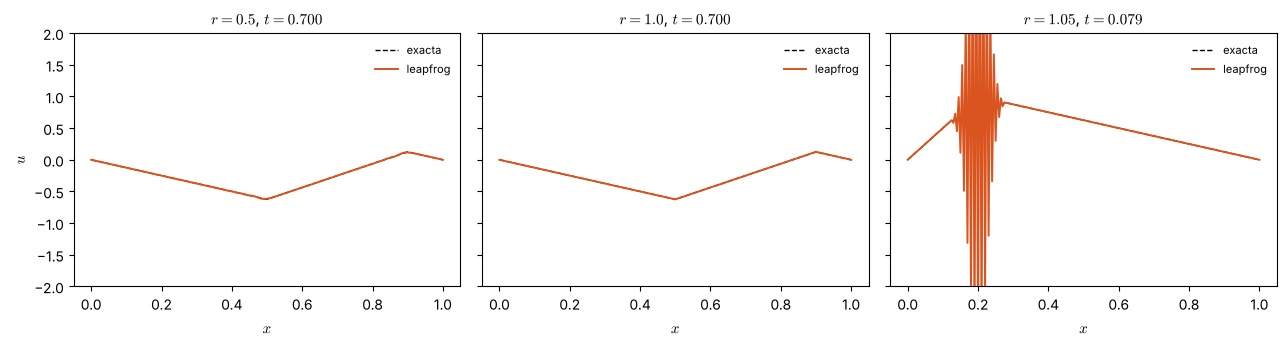

In [24]:
def leapfrog_mio(g, eta, c, dx, dt, pasos, primer_paso="taylor"):
    """u_tt = c^2 u_xx con extremos fijos. Devuelve u de forma (pasos+1, len(g))."""
    r = c * dt / dx
    u = np.zeros((pasos + 1, len(g))); u[0] = g
    u[1] = g + dt * eta
    if primer_paso == "taylor":
        u[1, 1:-1] += 0.5 * r ** 2 * (g[2:] - 2 * g[1:-1] + g[:-2])
    u[1, 0] = u[1, -1] = 0.0
    for n in range(1, pasos):
        u[n + 1, 1:-1] = 2 * u[n, 1:-1] - u[n - 1, 1:-1] + r ** 2 * (u[n, 2:] - 2 * u[n, 1:-1] + u[n, :-2])
    return u

# 1. orden con dato suave, t = 0.3
print("error en t = 0.3, r = 0.5:   N:   taylor      ingenuo")
res1 = {"taylor": [], "ingenuo": []}
Ns9 = np.array([20, 40, 80, 160])
for N in Ns9:
    dx = 1 / N; dt = 0.5 * dx; n = int(round(0.3 / dt)); xx = np.arange(N + 1) * dx
    for pp in res1:
        u = leapfrog_mio(np.sin(np.pi * xx), np.zeros_like(xx), 1.0, dx, dt, n, primer_paso=pp)
        res1[pp].append(np.abs(u[-1] - np.cos(np.pi * n * dt) * np.sin(np.pi * xx)).max())
    print(f"{N:>26d}   {res1['taylor'][-1]:.2e}   {res1['ingenuo'][-1]:.2e}")
for pp in res1:
    print(f"orden ({pp}): {orden_empirico(1 / Ns9, res1[pp], 3):.2f}")

# 2. cuerda pulsada
N = 200; dx = L / N; x = np.arange(N + 1) * dx
g_p = np.where(x <= x0, a * x / x0, a * (L - x) / (L - x0)); eta0 = np.zeros_like(x)
sol = {}
print("\n   r  |  error(t=0.3)  error(t=0.7) [vs serie] | error vs d'Alembert (t=0.7) | max|u|")
for r in [0.5, 1.0, 1.05]:
    dt = r * dx / c; n = int(round(0.7 / dt)); sol[r] = (dt, leapfrog_mio(g_p, eta0, c, dx, dt, n))
    dt_, u = sol[r]; i3 = int(round(0.3 / dt_))
    e3 = np.abs(u[i3] - serie_pulsada(x, i3 * dt_)).max(); e7 = np.abs(u[-1] - serie_pulsada(x, (len(u) - 1) * dt_)).max()
    ed = np.abs(u[-1] - dalembert_pulsada(x, (len(u) - 1) * dt_)).max()
    print(f"{r:5.2f} |   {e3:10.2e}   {e7:10.2e}          |        {ed:10.2e}           | {np.abs(u).max():.2e}")

fig, axs = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
for ax, r in zip(axs, [0.5, 1.0, 1.05]):
    dt_, u = sol[r]
    n_plot = len(u) - 1 if r <= 1 else int(np.argmax(np.abs(u).max(axis=1) > 3))
    ax.plot(x, dalembert_pulsada(x, n_plot * dt_), "k--", lw=1, label="exacta")
    ax.plot(x, u[n_plot], color=CICLO[1], lw=1.4, label="leapfrog")
    ax.set_title(f"$r={r}$, $t={n_plot * dt_:.3f}$"); ax.set_xlabel("$x$"); ax.set_ylim(-2, 2); ax.legend(fontsize=8, loc="upper right")
axs[0].set_ylabel("$u$")
fig.tight_layout()

# 3. dominios de dependencia
N3 = 400; j0 = 200; d0 = np.zeros(N3 + 1); d0[j0] = 1.0
print("\n   r  |  n  | semiancho numérico | r*n (frente exacto)")
for r in [0.5, 1.0, 1.05]:
    u = leapfrog_mio(d0, np.zeros_like(d0), 1.0, 1.0, r, 100)
    for n in [20, 50, 100]:
        j = np.nonzero(np.abs(u[n]) > 0)[0]
        print(f"{r:5.2f} | {n:3d} | {max(j.max() - j0, j0 - j.min()):8d}           | {r * n:8.1f}")

In [25]:
# Verificación
N_v = 100; dx_v = 1 / N_v; xv = np.arange(N_v + 1) * dx_v
gv = np.exp(-100 * (xv - 0.5) ** 2) * np.sin(np.pi * xv); ev = np.cos(3 * xv) * np.sin(np.pi * xv)
for r_v in (0.5, 1.0, 1.05):
    assert np.allclose(leapfrog_mio(gv, ev, 1.0, dx_v, r_v * dx_v, 60), numerico.ondas_leapfrog(gv, ev, 1.0, dx_v, r_v * dx_v, 60)), f"no coincide con imc.numerico.ondas_leapfrog (r = {r_v})"
assert 1.8 < orden_empirico(1 / Ns9, res1["taylor"], 3) < 2.2 and 0.8 < orden_empirico(1 / Ns9, res1["ingenuo"], 3) < 1.2, "órdenes 2 (Taylor) y 1 (ingenuo)"
assert np.abs(sol[1.0][1][-1] - dalembert_pulsada(x, (len(sol[1.0][1]) - 1) * sol[1.0][0])).max() < 1e-10, "r = 1 debería ser exacto en los nodos"
assert np.abs(sol[1.05][1]).max() > 1e5, "r = 1.05 debería explotar"
print("leapfrog: OK")

leapfrog: OK


## 10. Energía discreta y reflexión en un extremo libre

**Energía.** La energía continua es $E=\int_0^L\bigl(\frac12u_t^2+\frac{c^2}2u_x^2\bigr)dx$ y se conserva. Para el leapfrog hay una energía *discreta* que se conserva **exactamente** (salvo redondeo) cuando los extremos son fijos: multiplicando el esquema $\frac{u^{n+1}-2u^n+u^{n-1}}{k^2}=c^2D_2u^n$ por $\frac12(u^{n+1}-u^{n-1})$, sumando en $j$ (con peso $h$) y sumando por partes en el segundo miembro se obtiene $E^{n+1/2}=E^{n-1/2}$ con
$$E^{n+1/2}=\sum_j h\,\frac12\Bigl(\frac{u_j^{n+1}-u_j^n}{k}\Bigr)^2+\frac{c^2}2\sum_j h\,\frac{u_{j+1}^n-u_j^n}{h}\cdot\frac{u_{j+1}^{n+1}-u_j^{n+1}}{h}$$
(el segundo sumando es el producto de los cocientes incrementales espaciales en los *dos* niveles $n$ y $n+1$; la suma en $j$ va de $0$ a $N-1$). Una versión más ingenua, con el cuadrado de un solo nivel, $\frac{c^2}2\sum h\bigl(\frac{u^n_{j+1}-u^n_j}{h}\bigr)^2$, sólo se conserva *aproximadamente* (oscila con amplitud $O(k^2)$). Que se conserve no dice que el esquema sea estable: para $r>1$ la energía "conservada" es indefinida (no es una norma) y puede crecer.

**Extremo libre.** La condición $u_x(L,t)=0$ se discretiza con un *nodo ficticio* $u_{N+1}=u_{N-1}$ (simetría par respecto de $x=L$). Entonces la ecuación en el nodo $N$ queda
$$u_N^{n+1}=2u_N^n-u_N^{n-1}+2r^2\bigl(u_{N-1}^n-u_N^n\bigr),$$
y el mismo argumento vale para el primer paso. La energía discreta se conserva si la suma cinética usa **pesos de trapecio** ($h/2$ en el nodo libre).

**Qué esperar de la reflexión.** Con la extensión de d'Alembert: un extremo *fijo* refleja con *cambio de signo* (la extensión impar), uno *libre* con el *mismo signo* (la extensión par). Para el pulso $g(x-ct)$ que viaja hacia $x=L$ la solución exacta en $[0,L]$ es $g(x-ct)\mp g(2L-x-ct)$ (fijo/libre) mientras el pulso no llegue a $x=0$.

### Tarea 10: Energía discreta y reflexión (fijo/libre)

1. Escribí `energia_leapfrog(u, dx, dt, c, libre=False)`, que devuelve el array $E^{n+1/2}$, $n=0,\dots,\text{pasos}-1$, con la fórmula de arriba (pesos de trapecio en el nodo derecho si `libre=True`). Con la cuerda pulsada de la Tarea 9 ($N=200$, $t\le2$), graficá $E^{n+1/2}/E^{1/2}-1$ para $r=0.5,\,0.9,\,1$ (semilog del valor absoluto) y la versión ingenua para $r=0.9$.
2. Escribí `leapfrog_libre(g, eta, c, dx, dt, pasos)`: extremo izquierdo fijo y derecho libre. Con el pulso gaussiano $g=e^{-(x-0.6)^2/(2\cdot0.05^2)}$ que viaja hacia la derecha ($\eta=-cg'=c\frac{x-0.6}{0.05^2}g$), $N=400$, $r=1$, graficá los perfiles en $t=0.2,\,0.4,\,0.55,\,0.7$ para el extremo fijo (`leapfrog_mio`) y para el libre, junto con la solución exacta $g(x-ct)\mp g(2L-x-ct)$.
3. Comprobá que la energía (con `libre=True`) se conserva también en `leapfrog_libre`.

**Qué se espera.** (1) $E$ constante a $\sim10^{-14}$ para $r\le1$; la ingenua oscila con amplitud $\sim10^{-3}$. (2) Fijo: el pulso vuelve *invertido*; libre: vuelve *con el mismo signo*; en $t=0.4$ (llegada al extremo) el fijo tiene un pulso de amplitud cero en $x=1$ y el libre de amplitud doble (la superposición del pulso con su imagen); las dos numéricas coinciden con la exacta a $\sim10^{-3}$ o menos.

r = 0.5: E(0) = 3.118896; variación relativa máxima 5.6e-15
r = 0.9: E(0) = 3.105225; variación relativa máxima 3.6e-15
r = 1.0: E(0) = 3.100586; variación relativa máxima 2.4e-15
versión ingenua (r = 0.9): variación relativa máxima 1.6e-03
extremo fijo , t = 0.2: max|numérica - exacta| = 2.1e-04; u(L) = +0.000
extremo fijo , t = 0.4: max|numérica - exacta| = 2.1e-04; u(L) = +0.000
extremo fijo , t = 0.55: max|numérica - exacta| = 3.0e-04; u(L) = +0.000
extremo fijo , t = 0.7: max|numérica - exacta| = 2.1e-04; u(L) = +0.000
extremo libre, t = 0.2: max|numérica - exacta| = 2.1e-04; u(L) = +0.001
extremo libre, t = 0.4: max|numérica - exacta| = 4.2e-04; u(L) = +2.000
extremo libre, t = 0.55: max|numérica - exacta| = 3.0e-04; u(L) = +0.022
extremo libre, t = 0.7: max|numérica - exacta| = 2.1e-04; u(L) = +0.000


extremo libre: variación relativa de la energía 1.1e-15


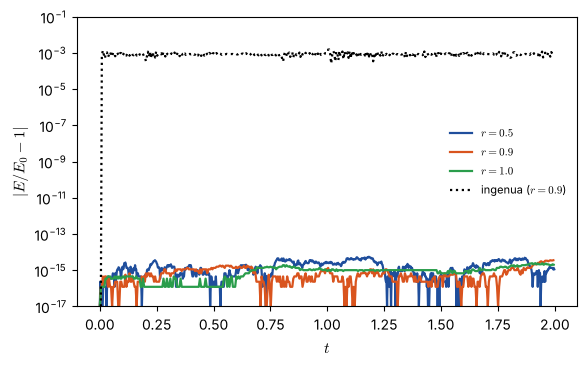

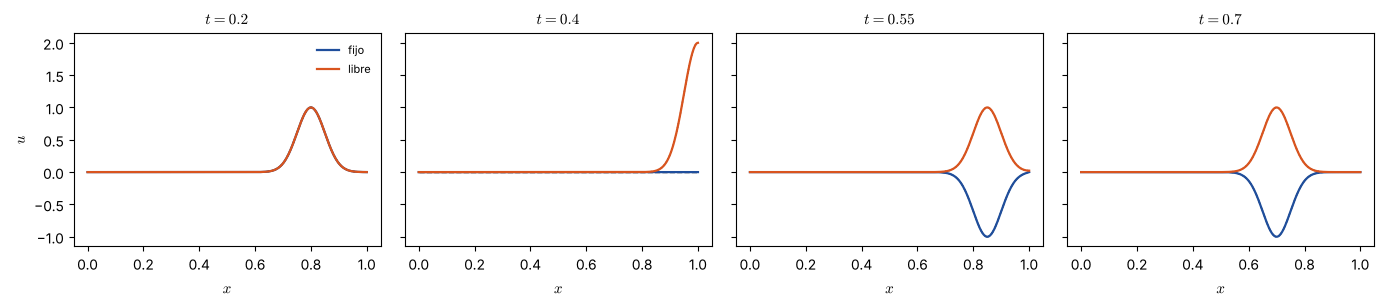

In [26]:
def energia_leapfrog(u, dx, dt, c, libre=False):
    """E^{n+1/2}, n = 0..pasos-1, del esquema leapfrog (u de forma (pasos+1, N+1))."""
    w = dx * np.ones(u.shape[1])
    if libre:
        w[-1] = dx / 2
    v = (u[1:] - u[:-1]) / dt                       # velocidad en n+1/2
    Du = np.diff(u, axis=1) / dx                    # incrementos espaciales (por celda) en cada nivel
    return 0.5 * (w * v ** 2).sum(axis=1) + 0.5 * c ** 2 * dx * (Du[:-1] * Du[1:]).sum(axis=1)

def leapfrog_libre(g, eta, c, dx, dt, pasos):
    """u_tt = c^2 u_xx, u(0,t) = 0, u_x(L,t) = 0 (nodo ficticio). Devuelve u de forma (pasos+1, len(g))."""
    r = c * dt / dx
    u = np.zeros((pasos + 1, len(g))); u[0] = g
    u[1, 1:-1] = g[1:-1] + dt * eta[1:-1] + 0.5 * r ** 2 * (g[2:] - 2 * g[1:-1] + g[:-2])
    u[1, -1] = g[-1] + dt * eta[-1] + r ** 2 * (g[-2] - g[-1])
    for n in range(1, pasos):
        u[n + 1, 1:-1] = 2 * u[n, 1:-1] - u[n - 1, 1:-1] + r ** 2 * (u[n, 2:] - 2 * u[n, 1:-1] + u[n, :-2])
        u[n + 1, -1] = 2 * u[n, -1] - u[n - 1, -1] + 2 * r ** 2 * (u[n, -2] - u[n, -1])
    return u

# 1. energía de la cuerda pulsada
N = 200; dx = L / N; x = np.arange(N + 1) * dx
g_p = np.where(x <= x0, a * x / x0, a * (L - x) / (L - x0))
fig, axs = plt.subplots(1, 1, figsize=(6, 3.8)); axs = [axs]
for r, c_ in zip([0.5, 0.9, 1.0], CICLO):
    dt = r * dx / c; n = int(round(2 / dt)); u = leapfrog_mio(g_p, np.zeros_like(x), c, dx, dt, n)
    E = energia_leapfrog(u, dx, dt, c)
    axs[0].semilogy(dt * np.arange(len(E)), np.abs(E / E[0] - 1) + 1e-17, color=c_, label=f"$r={r}$")
    print(f"r = {r}: E(0) = {E[0]:.6f}; variación relativa máxima {np.abs(E / E[0] - 1).max():.1e}")
r = 0.9; dt = r * dx / c; n = int(round(2 / dt)); u = leapfrog_mio(g_p, np.zeros_like(x), c, dx, dt, n)
v_c = (u[2:] - u[:-2]) / (2 * dt); Du_c = np.diff(u[1:-1], axis=1) / dx
En = dx * (0.5 * (v_c ** 2).sum(axis=1) + 0.5 * c ** 2 * (Du_c ** 2).sum(axis=1))
axs[0].semilogy(dt * (1 + np.arange(len(En))), np.abs(En / En[0] - 1) + 1e-17, "k:", label="ingenua ($r=0.9$)")
print(f"versión ingenua (r = 0.9): variación relativa máxima {np.abs(En / En[0] - 1).max():.1e}")
axs[0].set_xlabel("$t$"); axs[0].set_ylabel(r"$|E/E_0-1|$"); axs[0].legend(fontsize=8); axs[0].set_ylim(1e-17, 1e-1)

# 2. pulso contra un extremo fijo y uno libre
N2 = 400; dx2 = L / N2; x2 = np.arange(N2 + 1) * dx2; dt2 = dx2 / c
g_g = lambda s: np.exp(-(s - 0.6) ** 2 / (2 * 0.05 ** 2))
g0 = g_g(x2); eta_g = c * (x2 - 0.6) / 0.05 ** 2 * g0
n_max = int(round(0.7 / dt2))
u_fijo = leapfrog_mio(g0, eta_g, c, dx2, dt2, n_max); u_libre = leapfrog_libre(g0, eta_g, c, dx2, dt2, n_max)
tiempos = [0.2, 0.4, 0.55, 0.7]
for lado, sgn, u_ in [("fijo", -1, u_fijo), ("libre", +1, u_libre)]:
    for tt in tiempos:
        i = int(round(tt / dt2)); exacta = g_g(x2 - c * tt) + sgn * g_g(2 * L - x2 - c * tt)
        print(f"extremo {lado:5s}, t = {tt}: max|numérica - exacta| = {np.abs(u_[i] - exacta).max():.1e}; u(L) = {u_[i][-1]:+.3f}")
fig.tight_layout()

fig2, axs2 = plt.subplots(1, 4, figsize=(14, 3.2), sharey=True)
for ax, tt in zip(axs2, tiempos):
    i = int(round(tt / dt2))
    ax.plot(x2, g_g(x2 - c * tt) - g_g(2 * L - x2 - c * tt), "k--", lw=1)
    ax.plot(x2, g_g(x2 - c * tt) + g_g(2 * L - x2 - c * tt), "k:", lw=1)
    ax.plot(x2, u_fijo[i], color=CICLO[0], label="fijo"); ax.plot(x2, u_libre[i], color=CICLO[1], label="libre")
    ax.set_title(f"$t={tt}$"); ax.set_xlabel("$x$")
axs2[0].legend(fontsize=8); axs2[0].set_ylabel("$u$")
fig2.tight_layout()

E_libre = energia_leapfrog(u_libre, dx2, dt2, c, libre=True)
print(f"extremo libre: variación relativa de la energía {np.abs(E_libre / E_libre[0] - 1).max():.1e}")

In [27]:
# Verificación
Nv = 100; dxv = 1 / Nv; xv = np.arange(Nv + 1) * dxv
gv = np.sin(np.pi * xv) ** 2; ev = np.zeros_like(xv)
for r_v in (0.5, 1.0):
    uv = leapfrog_mio(gv, ev, 1.0, dxv, r_v * dxv, 300)
    Ev = energia_leapfrog(uv, dxv, r_v * dxv, 1.0)
    assert np.abs(Ev / Ev[0] - 1).max() < 1e-10, f"la energía debería conservarse (r = {r_v})"
assert abs(energia_leapfrog(leapfrog_mio(np.sin(np.pi * xv), ev, 1.0, dxv, dxv, 1), dxv, dxv, 1.0)[0] - np.pi ** 2 / 4) < 1e-2, "E = pi^2/4 para sin(pi x)"
uf = leapfrog_libre(np.cos(np.pi * xv / 2), ev, 1.0, dxv, dxv / 2, 40)     # modo cos(pi x/2): u(0) != 0, solo para probar la fila libre
assert np.allclose(uf[1, -1], uf[0, -1] + (dxv / 2 / dxv) ** 2 * (uf[0, -2] - uf[0, -1])), "primer paso en el nodo libre"
N2v = 400; dx2v = 1 / N2v; x2v = np.arange(N2v + 1) * dx2v
g2 = np.exp(-(x2v - 0.6) ** 2 / (2 * 0.05 ** 2)); e2 = (x2v - 0.6) / 0.05 ** 2 * g2
n7 = int(round(0.7 / dx2v))
uF = leapfrog_mio(g2, e2, 1.0, dx2v, dx2v, n7); uL = leapfrog_libre(g2, e2, 1.0, dx2v, dx2v, n7)
assert uF[-1].min() < -0.4 and uL[-1].max() > 0.4, "fijo: pulso invertido; libre: mismo signo"
EL = energia_leapfrog(uL, dx2v, dx2v, 1.0, libre=True)
assert np.abs(EL / EL[0] - 1).max() < 1e-10, "energía con extremo libre"
print("energía y extremo libre: OK")

energía y extremo libre: OK


## Interpretación

Esta es la parte que se evalúa. Respondé en las celdas de texto que siguen, con oraciones completas y citando los números o gráficos que obtuviste.

**1.** **Órdenes, bordes y periodicidad.** (a) Con la tabla de la Tarea 2: ¿por qué las funciones $u$ y $v$ se comportan distinto con los esquemas periódicos, y por qué forward *no* se rompe con $u$ mientras backward y centrada sí? (b) En la Tarea 5, ¿por qué con $f=\sin2\pi x$ el esquema (a) parece de orden 2 y con $f=\cos2\pi x$ es de orden 1? ¿Qué le dirías a alguien que concluye \"forward de orden 1 para Neumann es tan bueno como el de nodo ficticio\" a partir del primer experimento?

**2.** **Capa límite y Péclet.** Con los resultados de la Tarea 4: ¿a partir de qué $h$ (en función de $\varepsilon$) el esquema centrado deja de ser confiable? Explicá el mecanismo (coeficientes de la matriz, solución alternante de la ecuación en diferencias) y qué se ve en el gráfico. ¿Qué gana y qué pierde el esquema upwind? Interpretá \"difusión numérica\" con tus números (¿cuánto valía el ancho de la capa numérica con $h=0.1$ y $\varepsilon=0.01$?).

**3.** **Explícito, implícito y el teorema de Lax.** (a) Con las Tareas 6–8: enunciá la condición de estabilidad del explícito, explicá con el factor de amplificación qué modo la viola y por qué el serrucho crece, y explicá por qué $\sin\pi x$ tardó tanto más en explotar que la carpa con el mismo $r=0.52$. (b) El esquema explícito con $r=0.52$ es *consistente*: ¿por qué no converge? Citá los errores de la Tarea 7. (c) ¿Cuándo conviene el implícito y cuándo no? Usá los órdenes medidos con $r$ fijo y con $k=h$, y los tiempos de la Tarea 8.

**4.** **CFL y energía.** (a) Explicá la condición $r\le1$ con el dominio de dependencia, citando la tabla de semianchos de la Tarea 9. ¿Qué pasa con la solución numérica si $r=1.05$, y por qué *no* se arregla con \"más resolución\" (es decir, refinando $h$ y $k$ con $r$ fijo)? (b) ¿Qué ocurre para $r=1$ y por qué $r=0.5$ da ondulaciones detrás del frente? (c) La energía discreta se conserva a $\sim10^{-14}$ también para $r=1.05$ durante los primeros pasos. ¿Contradice esto que el esquema explote? (d) En la Tarea 10, ¿qué cambia en la reflexión al pasar de extremo fijo a libre y por qué (extensión impar contra par)?

### Respuestas modelo (para el docente)

**1.** (a) $v$ es suave como función periódica (todas sus derivadas coinciden en los extremos), así que la extensión periódica es tan suave como $v$ y los esquemas periódicos son de orden 1, 1, 2, 2, 4 como siempre. $u$ cumple $u(0)=u(1)$ pero $u'(0)=1-\ln2\ne u'(1)=\frac12-\ln2$: la extensión tiene una punta y un esquema que mezcla valores de los dos lados en $x_0$ o $x_{N}$ comete error $O(1)$ ahí (backward en $x_0$: $0.4995$; centrada: $0.2507$; los de orden 2 y 4: $0.5$ y $0.25$); el error no baja con $h$ (orden 0). Forward se salva porque en el último nodo usa $u(x_N)=u(x_0)$, valor verdadero (los dos coinciden), y en $x_0$ usa $x_1$, del lado correcto: nunca ve del otro lado un valor "equivocado". (b) Con $f(0)=0$ las filas (a) y (b) son idénticas ($\frac{U_1-U_0}h=\frac h2f(0)=0$). Con $f=\cos$, $f(0)=1$, el error de truncamiento de (a) en la fila 0 es $\frac h2$ y el error global es $O(h)$ ($1.00$ medido), contra $2.00$ de (b). Un solo experimento con $f(0)=0$ oculta la diferencia: hay que probar con datos genéricos.

**2.** El centrado falla mientras $h>2\varepsilon$ ($\mathrm{Pe}_h>1$): el coeficiente de $U_{j+1}$, $\varepsilon/h^2-1/(2h)$, se hace negativo; la solución homogénea $\lambda^j$ con $\lambda=\frac{1+\mathrm{Pe}}{1-\mathrm{Pe}}<0$ alterna de signo. En el gráfico ($\varepsilon=0.01$, $h=0.1$) se ve un zigzag que llena todo el intervalo, con error $\sim0.7$ (del orden del salto de la capa); con $h<2\varepsilon$ el error baja con pendiente 2 (para $\varepsilon=0.001$, recién para $h<0.002$). Upwind: sin oscilaciones para todo $h$ (matriz con coeficientes de buen signo, principio del máximo discreto), pero orden 1 y capa ensanchada: agrega difusión $h/2$, o sea la solución es la de $\varepsilon+h/2=0.06$ en lugar de $0.01$ para $h=0.1$: el ancho de capa numérico es $\sim6$ veces el real.

**3.** (a) $r=\alpha k/h^2\le\frac12$; $g(\theta)=1-4r\sin^2\frac\theta2\ge1-4r$, mínimo en $\theta=\pi$ (modo serrucho); si $r>\frac12$, $|1-4r|>1$: el serrucho se multiplica por $-1.08$ (para $r=0.52$) en cada paso. $\sin\pi x_j$ es autovector y su componente en el modo $k=N-1$ es $10^{-17}$; hacen falta unos $\ln10^{16}/\ln1.08\approx480$ pasos de crecimiento para que aparezca, mientras el modo fundamental decae. La carpa ($2.5\times10^{-3}$) y $x(1-x)$ ($10^{-5}$) tienen componente mucho mayor en ese modo y explotan antes de 200 pasos. (b) Porque falta la estabilidad: Lax dice consistente + estable $\Leftrightarrow$ convergente. Errores en $T=0.1$: decrecen de $N=10$ a $20$ y explotan ($>1$) en $N=80$, donde hay $\sim1200$ pasos. (c) Con $r$ fijo el orden es 2 (igual que el explícito con $r=\frac12$) y el costo por paso es el mismo orden $O(m)$, sin beneficio; con $k=h$ hay menos pasos ($1/h$ en lugar de $1/h^2$) pero el orden cae a 1 (domina $O(k)$). El implícito conviene cuando el paso está limitado por estabilidad y no por precisión (rigidez, régimen estacionario, dato no suave) y con Crank–Nicolson. Tiempos: la versión densa crece entre $4\times$ y $8\times$ por duplicación de $N$ (cociente $14$, $54$, $245$ contra `solve_banded`); `solve_banded` es casi constante en el rango.

**4.** (a) $s_n=n$ para todo $r$ (el esquema mira un nodo por paso); el frente de la ecuación está en $rn$: $50$ para $r=1$, $52.5$ para $r=1.05$ (el frente exacto queda 2.5 nodos fuera del dominio numérico a los 50 pasos, y 5 a los 100). Con $r=1.05$ la solución numérica no puede conocer el dato que determina la exacta: no converge. Refinar con $r$ fijo no ayuda, porque la razón entre dominios es siempre $1.05$; y la inestabilidad de von Neumann ($|g|>1$ en $\theta=\pi$) crece en cada paso a partir del redondeo. (b) Con $r=1$ el esquema es d'Alembert discreto: los datos se trasladan exactamente un nodo por paso ($\sim10^{-15}$ de error). Con $r<1$ es disperso: las ondas cortas viajan con velocidad menor que $c$, y los cambios bruscos (esquinas) se ven seguidos por ondulaciones. (c) No hay contradicción: para $r>1$ la forma cuadrática es indefinida: la energía puede ser constante mientras una parte crece y otra decrece; sólo para $r\le1$ es definida positiva y acota la solución. (d) Fijo: extensión impar, el pulso vuelve invertido y con amplitud cero en $x=L$ en el instante de la llegada; libre: extensión par, vuelve con el mismo signo, y en el instante de la llegada duplica la amplitud en $x=L$.

**Tiempos.** Parte A (Tareas 1–5): ~2 h 15; Parte B (Tareas 6–10): ~2 h 30; interpretación: 40 minutos en casa. Con una sola sesión de 4 h, dar resueltas las Tareas 1 y 5 y pedir Tareas 2, 4, 6, 9 (las más ricas).

## Cobertura de los ejercicios del texto y ejercicios adicionales

Los enunciados de la sección "Ejercicios de laboratorio" de la Parte III (Sección 21.2), por tema, y dónde se resuelven:

* Matrices de diferenciación forward/backward/centrada, no periódicas y periódicas: Tarea 1.
* Interpolación, fórmulas de orden superior y matrices periódicas: explicación y "Para pensar" de la Sección 1; el ítem (c) en la Tarea 1 (y su orden en la Tarea 2).
* Orden de convergencia de los métodos de diferenciación (con $u$ y $v$; periódicas sobre $u$): Tarea 2.
* Condiciones de Dirichlet (a)–(c): Tarea 3 (con `solve_banded` de agregado).
* Capa límite en el borde (a), (b): Tarea 4 (con upwind de agregado).
* Condiciones de Neumann: Tarea 5 (con $f=\cos2\pi x$ de agregado).
* Esquema explícito (forward en el tiempo) para $U_t=\alpha U_{xx}$ y la condición $r\le 1/2$, (a)–(c): explicación y "Para pensar" de la Sección 6 (los ítems demostrativos); se verifican numéricamente en las Tareas 6 y 7 (incluido el caso $r=1/6$).
* Programa del esquema explícito con datos iniciales dados (a), (b): Tarea 6; (c): Tarea 7.
* Método implícito: Tarea 8.
* Esquema explícito (leapfrog) para la ecuación de ondas, ítems 1, 2: Tarea 9; ítem 3: Tarea 10; ítem 4 (fijo y libre): Tarea 10.

**Para experimentar.**

* Con `numerico.calor_explicito_2d` resolvé el calor en el cuadrado y encontrá, mirando cuándo explota, la condición $r\le\frac14$ (von Neumann en 2D: $g=1-4r(\sin^2\frac{\theta_1}2+\sin^2\frac{\theta_2}2)$).
* Corré Crank–Nicolson con la carpa y $r=100$: ¿qué pasa con el serrucho? Compará con el implícito.
* Graficá el error del leapfrog con $r=0.5$ contra $t$ para la cuerda pulsada: ¿crece como $t$ (fase acumulada) o se estabiliza? Ajustá la relación de dispersión numérica $\omega_h(\theta)$ y comparala con $c\theta/h$.
* El ejercicio de la temperatura del suelo (Parte III) usa el esquema explícito de la Tarea 6 con condición de borde variable en el tiempo: adaptá `calor_explicito_mio` a `borde=(f_izq(t), 0)` y verificá $r\le\frac12$ para un $D$ típico del suelo.